# Polish Company Bankruptcy Prediction
**MSIN0097 — Predictive Analytics | Individual Coursework**

**Dataset:** Polish Companies Bankruptcy Data (UCI Machine Learning Repository)  
**Task:** Binary classification — predict company bankruptcy (class 1) vs. survival (class 0)  
**Primary Metrics:** AUC-ROC, F1-Score, and Recall — bankrupt class (NOT accuracy — dataset is severely imbalanced ~4–7% bankruptcy rate)  

---

## Notebook Structure (6 Steps per Brief)
1. **Obtain dataset & frame the predictive problem**
2. Explore the data to gain insights (EDA)
3. Prepare the data
4. Explore different models & shortlist the best
5. Fine-tune and evaluate
6. Present the final solution

---
## Step 1: Obtain Dataset & Frame the Predictive Problem

### 1.1 Problem Framing

The task is binary bankruptcy prediction using the Polish Companies Bankruptcy dataset (Zieba, Tomczak and Tomczak, 2016) — five annual cohorts of Polish companies (years 1–5), 43,405 rows, 64 named financial ratio features.

**Target Variable:** Binary `class`(1 = bankrupt, 0 = survived); consistent with the discriminant-analysis tradition of Beaver (1966) and Altman (1968).

**Prediction type** Binary classification

**Horizon:** 1–5 years before bankruptcy (five annual snapshots)

**Success Metrics:** 
- Primary: AUC-ROC — threshold-independent, robust to imbalance
- Secondary: F1-Score (bankrupt class) — balances precision and recall
- Tertiary: Recall (bankrupt class) — proportion of actual bankruptcies caught; most domain-critical given the high cost of false negatives
- Accuracy excluded — naive classifier scores ~95% by predicting all surviving

**Constraints:** 
- No data leakage between train/val/test
- Fixed random seed (42) for reproducibility
- Temporal split required — prediction is inherently a future-facing task (year 1-3 / 4 / 5 for train / val / test respectively)

**Key Limitations:** 
- Limitations including calibration, temporal generalisability, and firm-level identifiability — are discussed in step 6.
- Missingness mechanism investigated in step2, EDA
- Feature mapping documented in step 1.5, Data Dictionary

### 1.2 Imports

In [93]:
import numpy as np
import pandas as pd
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed (used throughout the project)
RANDOM_SEED = 42

print('Libraries loaded successfully.')
print(f'pandas version : {pd.__version__}')
print(f'numpy version  : {np.__version__}')

Libraries loaded successfully.
pandas version : 3.0.1
numpy version  : 2.4.2


### 1.3 Load & Combine All 5 ARFF Files

In [94]:
DATA_DIR = '.'  # All .arff files are in the same directory as this notebook

dfs = []

for year in range(1, 6):
    filepath = f'{DATA_DIR}/{year}year.arff'
    
    # Load ARFF file — returns (data, meta)
    data, meta = arff.loadarff(filepath)
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    # Add year identifier column
    df['year'] = year
    
    dfs.append(df)
    print(f'  Loaded {year}year.arff — shape: {df.shape}')

# Concatenate all years into one DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Decode 'class' column from bytes (b'0', b'1') to integer (0, 1)
# ARFF categorical values are loaded as byte strings by scipy
combined_df['class'] = combined_df['class'].apply(
    lambda x: int(x.decode('utf-8')) if isinstance(x, bytes) else int(x)
)

print(f'\nAll files loaded and combined successfully.')

  Loaded 1year.arff — shape: (7027, 66)
  Loaded 2year.arff — shape: (10173, 66)
  Loaded 3year.arff — shape: (10503, 66)
  Loaded 4year.arff — shape: (9792, 66)
  Loaded 5year.arff — shape: (5910, 66)

All files loaded and combined successfully.


### 1.4 — Dataset Overview

In [95]:
import pandas as pd

# ── Shape ─────────────────────────────────────────────────────────────────────
print("=" * 65)
print("1. DATASET SHAPE")
print("=" * 65)
print(f"  Rows    : {combined_df.shape[0]:,}")
print(f"  Columns : {combined_df.shape[1]}  (64 ratio features + 'year' + 'class')")
print()
rows_per_year = combined_df.groupby('year').size().rename('rows')
for yr, n in rows_per_year.items():
    print(f"  Year {yr} : {n:,} rows")

# ── Data types ────────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("2. DATA TYPES")
print("=" * 65)
for dtype, count in combined_df.dtypes.value_counts().items():
    print(f"  {str(dtype):<12} : {count} column(s)")
null_total = combined_df.isna().sum().sum()
print(f"  Missing values : {null_total:,}  ({null_total / combined_df.size * 100:.1f}% of all values)")

# ── First 5 rows ──────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("3. FIRST 5 ROWS  (first 6 feature columns shown)")
print("=" * 65)
feature_preview = [c for c in combined_df.columns if c not in ["year","class"]][:6]
preview_cols = feature_preview + ["year", "class"]
pd.set_option("display.float_format", "{:>10.4f}".format)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 130)
print(combined_df[preview_cols].head(5).to_string(index=True))
pd.reset_option("display.float_format")
pd.reset_option("display.max_columns")
pd.reset_option("display.width")


1. DATASET SHAPE
  Rows    : 43,405
  Columns : 66  (64 ratio features + 'year' + 'class')

  Year 1 : 7,027 rows
  Year 2 : 10,173 rows
  Year 3 : 10,503 rows
  Year 4 : 9,792 rows
  Year 5 : 5,910 rows

2. DATA TYPES
  float64      : 64 column(s)
  int64        : 2 column(s)
  Missing values : 41,322  (1.4% of all values)

3. FIRST 5 ROWS  (first 6 feature columns shown)
       Attr1      Attr2      Attr3      Attr4      Attr5      Attr6  year  class
0     0.2006     0.3795     0.3964     2.0472    32.3510     0.3882     1      0
1     0.2091     0.4999     0.4723     1.9447    14.7860     0.0000     1      0
2     0.2487     0.6959     0.2671     1.5548    -1.1523     0.0000     1      0
3     0.0815     0.3073     0.4588     2.4928    51.9520     0.1499     1      0
4     0.1873     0.6132     0.2296     1.4063    -7.3128     0.1873     1      0


### 1.5 — Data Dictionary: Feature Mapping

All 64 features are named financial ratios documented in the UCI Polish Companies Bankruptcy dataset (Zieba, Tomczak and Tomczak, 2016). Column names in the DataFrame use the `Attr` convention; the UCI paper uses `X` notation. Both are shown below alongside the full ratio description.

| Column | UCI Notation | Financial Ratio Description |
|--------|-------------|----------------------------|
| `Attr1` | X1 | net profit / total assets |
| `Attr2` | X2 | total liabilities / total assets |
| `Attr3` | X3 | working capital / total assets |
| `Attr4` | X4 | current assets / short-term liabilities |
| `Attr5` | X5 | [(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] × 365 |
| `Attr6` | X6 | retained earnings / total assets |
| `Attr7` | X7 | EBIT / total assets |
| `Attr8` | X8 | book value of equity / total liabilities |
| `Attr9` | X9 | sales / total assets |
| `Attr10` | X10 | equity / total assets |
| `Attr11` | X11 | (gross profit + extraordinary items + financial expenses) / total assets |
| `Attr12` | X12 | gross profit / short-term liabilities |
| `Attr13` | X13 | (gross profit + depreciation) / sales |
| `Attr14` | X14 | (gross profit + interest) / total assets |
| `Attr15` | X15 | (total liabilities × 365) / (gross profit + depreciation) |
| `Attr16` | X16 | (gross profit + depreciation) / total liabilities |
| `Attr17` | X17 | total assets / total liabilities |
| `Attr18` | X18 | gross profit / total assets |
| `Attr19` | X19 | gross profit / sales |
| `Attr20` | X20 | (inventory × 365) / sales |
| `Attr21` | X21 | sales (n) / sales (n-1)  [sales growth rate] |
| `Attr22` | X22 | profit on operating activities / total assets |
| `Attr23` | X23 | net profit / sales |
| `Attr24` | X24 | gross profit (in 3 years) / total assets |
| `Attr25` | X25 | (equity - share capital) / total assets |
| `Attr26` | X26 | (net profit + depreciation) / total liabilities |
| `Attr27` | X27 | profit on operating activities / financial expenses |
| `Attr28` | X28 | working capital / fixed assets |
| `Attr29` | X29 | logarithm of total assets |
| `Attr30` | X30 | (total liabilities - cash) / sales |
| `Attr31` | X31 | (gross profit + interest) / sales |
| `Attr32` | X32 | (current liabilities × 365) / cost of products sold |
| `Attr33` | X33 | operating expenses / short-term liabilities |
| `Attr34` | X34 | operating expenses / total liabilities |
| `Attr35` | X35 | profit on sales / total assets |
| `Attr36` | X36 | total sales / total assets |
| `Attr37` | X37 | (current assets - inventories) / long-term liabilities |
| `Attr38` | X38 | constant capital / total assets |
| `Attr39` | X39 | profit on sales / sales |
| `Attr40` | X40 | (current assets - inventory - receivables) / short-term liabilities |
| `Attr41` | X41 | total liabilities / ((profit on operating activities + depreciation) × (12/365)) |
| `Attr42` | X42 | profit on operating activities / sales |
| `Attr43` | X43 | rotation receivables + inventory turnover in days |
| `Attr44` | X44 | (receivables × 365) / sales |
| `Attr45` | X45 | net profit / inventory |
| `Attr46` | X46 | (current assets - inventory) / short-term liabilities |
| `Attr47` | X47 | (inventory × 365) / cost of products sold |
| `Attr48` | X48 | EBITDA (profit on operating activities - depreciation) / total assets |
| `Attr49` | X49 | EBITDA (profit on operating activities - depreciation) / sales |
| `Attr50` | X50 | current assets / total liabilities |
| `Attr51` | X51 | short-term liabilities / total assets |
| `Attr52` | X52 | (short-term liabilities × 365) / cost of products sold |
| `Attr53` | X53 | equity / fixed assets |
| `Attr54` | X54 | constant capital / fixed assets |
| `Attr55` | X55 | working capital |
| `Attr56` | X56 | (sales - cost of products sold) / sales |
| `Attr57` | X57 | (current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation) |
| `Attr58` | X58 | total costs / total sales |
| `Attr59` | X59 | long-term liabilities / equity |
| `Attr60` | X60 | sales / inventory |
| `Attr61` | X61 | sales / receivables |
| `Attr62` | X62 | (short-term liabilities × 365) / sales |
| `Attr63` | X63 | sales / short-term liabilities |
| `Attr64` | X64 | sales / fixed assets |

---
## Step 2: Explore the Data to Gain Insights (EDA)

> ⚠️ **Data discipline:** Section 2.1 uses the full dataset to characterise class distribution across all years and confirm the temporal split decision (see Section 1.1).  
> All remaining EDA (Section 2.2 onwards) is performed on the **training set only** (Years 1–3).  
> Years 4 and 5 are held out as validation and test sets and must **not** be examined during exploration.

### 2.1 Class Distribution Across All Years

This section uses the **full combined dataset** (all 5 years) to examine how the bankruptcy rate varies across the temporal span of the data. The monotonic increase in bankruptcy rate across years is the key evidence that justifies a **year-based temporal split** over random stratified sampling.

CLASS DISTRIBUTION PER YEAR (All 5 Years)
class  Surviving  Bankrupt  Total  Bankrupt Rate %
year                                              
1           6756       271   7027             3.86
2           9773       400  10173             3.93
3          10008       495  10503             4.71
4           9277       515   9792             5.26
5           5500       410   5910             6.94

Overall bankruptcy rate (all years): 4.82%
NOTE: AUC-ROC, F1-Score, and Recall (bankrupt class) are used; accuracy is not reported due to imbalance.


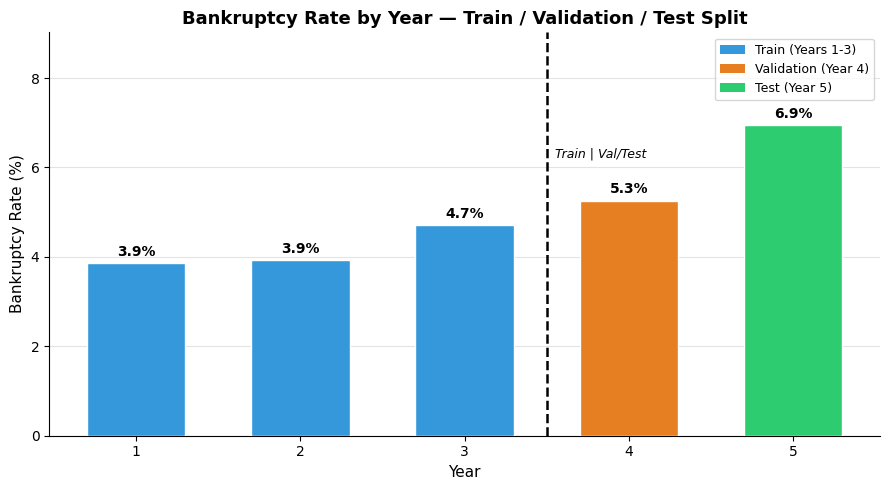

Saved: eda_1_class_distribution_by_year.png


In [96]:
# ── Tabular summary ──────────────────────────────────────────────────────────
print('=' * 60)
print('CLASS DISTRIBUTION PER YEAR (All 5 Years)')
print('=' * 60)
per_year = (
    combined_df.groupby(['year', 'class'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Surviving', 1: 'Bankrupt'})
)
per_year['Total']           = per_year.sum(axis=1)
per_year['Bankrupt Rate %'] = (per_year['Bankrupt'] / per_year['Total'] * 100).round(2)
print(per_year.to_string())
print()
overall_rate = combined_df['class'].mean() * 100
print(f'Overall bankruptcy rate (all years): {overall_rate:.2f}%')
print('NOTE: AUC-ROC, F1-Score, and Recall (bankrupt class) are used; accuracy is not reported due to imbalance.')

# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

rates  = per_year['Bankrupt Rate %'].values
years  = per_year.index.tolist()
colors = ['#3498db' if y <= 3 else '#e67e22' if y == 4 else '#2ecc71' for y in years]
labels = {1: 'Train', 2: 'Train', 3: 'Train', 4: 'Validation', 5: 'Test'}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(years, rates, color=colors, edgecolor='white', width=0.6, zorder=3)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axvline(3.5, color='black', linestyle='--', linewidth=1.8, zorder=4)
ax.text(3.55, max(rates) * 0.93, 'Train | Val/Test', ha='left', va='top',
        fontsize=9, color='black', style='italic')

legend_elements = [
    mpatches.Patch(facecolor='#3498db', label='Train (Years 1-3)'),
    mpatches.Patch(facecolor='#e67e22', label='Validation (Year 4)'),
    mpatches.Patch(facecolor='#2ecc71', label='Test (Year 5)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Bankruptcy Rate (%)', fontsize=11)
ax.set_title('Bankruptcy Rate by Year — Train / Validation / Test Split',
             fontsize=13, fontweight='bold')
ax.set_xticks(years)
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(True, axis='y', alpha=0.35, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_1_class_distribution_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_1_class_distribution_by_year.png')


In [97]:
# ─────────────────────────────────────────────────────────────────────────────
# Temporary EDA scope — training years only (Years 1–3)
# Section 2.2–Section 2.6 below are conducted strictly on this subset to prevent any
# information from validation (Year 4) or test (Year 5) sets influencing
# preprocessing decisions.
# Formal split with sizes, rationale, and leakage contract defined in Section 3.1
# ─────────────────────────────────────────────────────────────────────────────
df_train = combined_df[combined_df["year"].isin([1, 2, 3])].copy()
df_train = df_train.reset_index(drop=True)

> ⚠️ **EDA Data Discipline — applies to all sections below (Section 2.2–Section 2.6)**
>
> - **Training set only:** All EDA from Section 2.2 onwards uses `df_train` (Years 1–3 only). Years 4 and 5 are held out and must not be examined during exploration — inspecting them here would constitute data leakage.
> - **Top 10 in charts:** All visualisations show the top 10 features for readability. All 64 features are retained for modelling — no features are dropped based on EDA visualisations alone.

### 2.2 Missing Value Analysis

Two aspects are examined:

1. **Overall missingness** — which of the 64 features contain missing values and how severe the missingness is.
2. **Consistency across years** — whether missingness rates are stable across Years 1–3 (structural / MNAR) or vary substantially (random / MAR), determining how safely we can impute.

MISSING VALUE SUMMARY (df_train, years 1-3)
Total features         : 64
Features with any NaN  : 64
Features with >30% NaN : 1
Features fully present : 0

Top 10 most-missing features:
(current assets - inventories) / long-term liabilities          43.29
sales (n) / sales (n-1)                                         20.19
profit on operating activities / financial expenses              6.25
sales / inventory                                                4.58
net profit / inventory                                           4.57
gross profit (in 3 years) / total assets                         2.08
total liabilities / ((op. profit + depreciation) * (12/365))     1.74
equity / fixed assets                                            1.71
constant capital / fixed assets                                  1.71
working capital / fixed assets                                   1.71


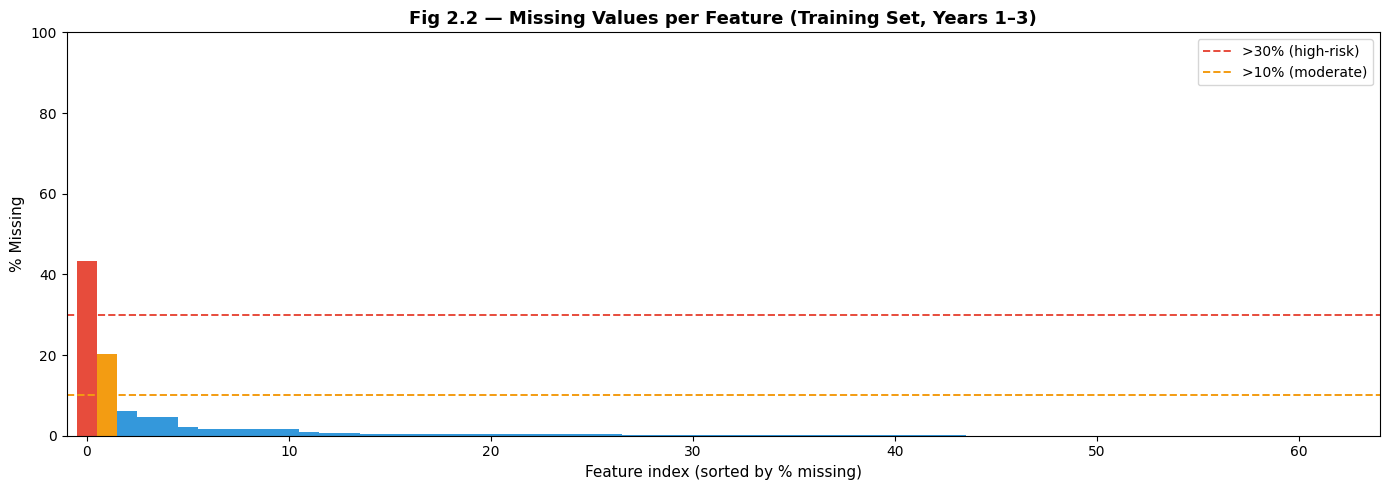


Plot saved: eda_2_2_missing_values.png


In [98]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

feature_cols = [c for c in df_train.columns if c not in ["year", "class"]]

FEATURE_NAMES = {
    'Attr1': 'net profit / total assets',
    'Attr2': 'total liabilities / total assets',
    'Attr3': 'working capital / total assets',
    'Attr4': 'current assets / short-term liabilities',
    'Attr5': '[(cash + ST securities + receivables - ST liabilities) / (op. expenses - depreciation)] * 365',
    'Attr6': 'retained earnings / total assets',
    'Attr7': 'EBIT / total assets',
    'Attr8': 'book value of equity / total liabilities',
    'Attr9': 'sales / total assets',
    'Attr10': 'equity / total assets',
    'Attr11': '(gross profit + extraordinary items + fin. expenses) / total assets',
    'Attr12': 'gross profit / short-term liabilities',
    'Attr13': '(gross profit + depreciation) / sales',
    'Attr14': '(gross profit + interest) / total assets',
    'Attr15': '(total liabilities * 365) / (gross profit + depreciation)',
    'Attr16': '(gross profit + depreciation) / total liabilities',
    'Attr17': 'total assets / total liabilities',
    'Attr18': 'gross profit / total assets',
    'Attr19': 'gross profit / sales',
    'Attr20': '(inventory * 365) / sales',
    'Attr21': 'sales (n) / sales (n-1)',
    'Attr22': 'profit on operating activities / total assets',
    'Attr23': 'net profit / sales',
    'Attr24': 'gross profit (in 3 years) / total assets',
    'Attr25': '(equity - share capital) / total assets',
    'Attr26': '(net profit + depreciation) / total liabilities',
    'Attr27': 'profit on operating activities / financial expenses',
    'Attr28': 'working capital / fixed assets',
    'Attr29': 'logarithm of total assets',
    'Attr30': '(total liabilities - cash) / sales',
    'Attr31': '(gross profit + interest) / sales',
    'Attr32': '(current liabilities * 365) / cost of products sold',
    'Attr33': 'operating expenses / short-term liabilities',
    'Attr34': 'operating expenses / total liabilities',
    'Attr35': 'profit on sales / total assets',
    'Attr36': 'total sales / total assets',
    'Attr37': '(current assets - inventories) / long-term liabilities',
    'Attr38': 'constant capital / total assets',
    'Attr39': 'profit on sales / sales',
    'Attr40': '(current assets - inventory - receivables) / short-term liabilities',
    'Attr41': 'total liabilities / ((op. profit + depreciation) * (12/365))',
    'Attr42': 'profit on operating activities / sales',
    'Attr43': 'receivables + inventory turnover in days',
    'Attr44': '(receivables * 365) / sales',
    'Attr45': 'net profit / inventory',
    'Attr46': '(current assets - inventory) / short-term liabilities',
    'Attr47': '(inventory * 365) / cost of products sold',
    'Attr48': 'EBITDA / total assets',
    'Attr49': 'EBITDA / sales',
    'Attr50': 'current assets / total liabilities',
    'Attr51': 'short-term liabilities / total assets',
    'Attr52': '(short-term liabilities * 365) / cost of products sold',
    'Attr53': 'equity / fixed assets',
    'Attr54': 'constant capital / fixed assets',
    'Attr55': 'working capital',
    'Attr56': '(sales - cost of products sold) / sales',
    'Attr57': '(current assets - inventory - ST liabilities) / (sales - gross profit - depreciation)',
    'Attr58': 'total costs / total sales',
    'Attr59': 'long-term liabilities / equity',
    'Attr60': 'sales / inventory',
    'Attr61': 'sales / receivables',
    'Attr62': '(short-term liabilities * 365) / sales',
    'Attr63': 'sales / short-term liabilities',
    'Attr64': 'sales / fixed assets',
}


missing_pct = (df_train[feature_cols].isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_any = (missing_pct > 0).sum()
missing_over30 = (missing_pct > 30).sum()

print("=" * 55)
print("MISSING VALUE SUMMARY (df_train, years 1-3)")
print("=" * 55)
print(f"Total features         : {len(feature_cols)}")
print(f"Features with any NaN  : {missing_any}")
print(f"Features with >30% NaN : {missing_over30}")
print(f"Features fully present : {len(feature_cols) - missing_any}")
print()
print("Top 10 most-missing features:")
missing_pct_named = missing_pct.copy()
missing_pct_named.index = [FEATURE_NAMES.get(f, f) for f in missing_pct_named.index]
print(missing_pct_named.head(10).round(2).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if v > 30 else "#f39c12" if v > 10 else "#3498db"
          for v in missing_pct.values]
ax.bar(range(len(missing_pct)), missing_pct.values, color=colors, width=1.0)
ax.axhline(30, color="#e74c3c", linestyle="--", lw=1.4, label=">30% (high-risk)")
ax.axhline(10, color="#f39c12", linestyle="--", lw=1.4, label=">10% (moderate)")
ax.set_xlabel("Feature index (sorted by % missing)", fontsize=11)
ax.set_ylabel("% Missing", fontsize=11)
ax.set_title("Fig 2.2 — Missing Values per Feature (Training Set, Years 1–3)",
             fontsize=13, fontweight="bold")
ax.set_xlim(-1, len(missing_pct))
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eda_2_2_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved: eda_2_2_missing_values.png")

**Interpretation:** The majority of the 64 features contain some missing values, with a subset
exceeding 30% missingness (red bars). Missing values in financial datasets often arise because
certain ratios cannot be computed (e.g. division by zero when a balance-sheet item is absent),
meaning they are likely **Missing Not At Random (MNAR)** rather than random noise.
In Step 3, we will apply **median imputation** fitted on the training set only — dropping
features with very high missingness would risk discarding potentially discriminative signals.

**Part 2 — Missingness Consistency Across Years (MNAR Check)**

% Missing per year for top 10 most-missing features:
   (current assets - inventories) / long-term liabilities  sales (n) / sales (n-1)  profit on operating activities / financial expenses  sales / inventory  net profit / inventory  gross profit (in 3 years) / total assets  total liabilities / ((op. profit + depreciation) * (12/365))  equity / fixed assets  constant capital / fixed assets  working capital / fixed assets
1                                                   38.99                    23.08                                                 4.43               1.92                    1.91                                      1.76                                                          1.20                   0.48                             0.48                            0.48
2                                                   44.41                    31.10                                                 6.94               5.34                    5.32                           

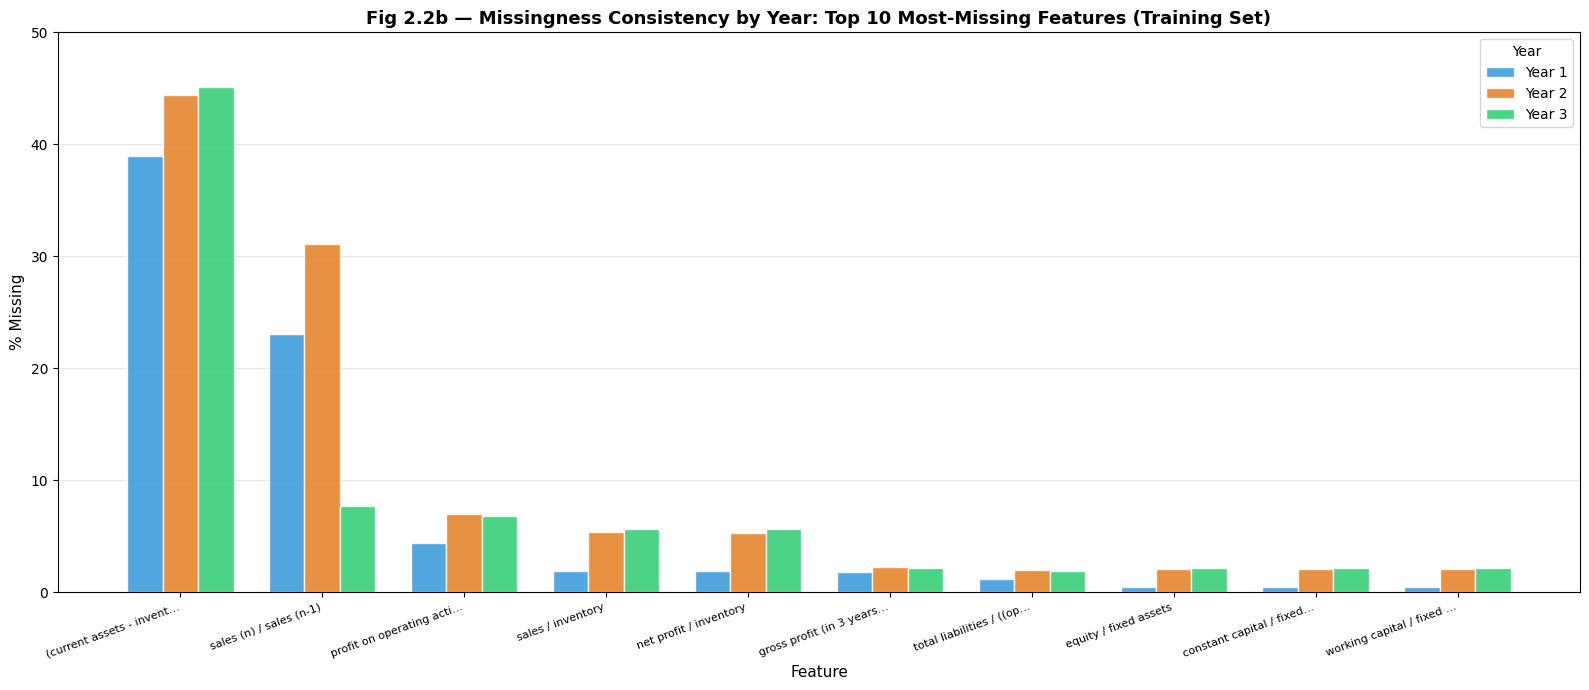

Plot saved: eda_2_2b_missing_by_year.png


In [99]:
top10_miss = missing_pct.head(10).index.tolist()

miss_by_year = {}
for yr in [1, 2, 3]:
    yr_df = df_train[df_train["year"] == yr]
    miss_by_year[yr] = yr_df[top10_miss].isnull().mean() * 100
miss_by_year_df = pd.DataFrame(miss_by_year).T

# Rename columns to real names for display
miss_by_year_df.columns = [FEATURE_NAMES.get(f, f) for f in miss_by_year_df.columns]
top10_miss_named = [FEATURE_NAMES.get(f, f) for f in top10_miss]
print("% Missing per year for top 10 most-missing features:")
print(miss_by_year_df.round(2).to_string())
print()
stdev = miss_by_year_df.std(axis=0).sort_values(ascending=False)
print("Std dev across years (high = inconsistent = more random):")
print(stdev.round(2).to_string())

# Grouped bar chart: each feature has 3 bars side-by-side (one per year)
import numpy as np
n_feats = len(top10_miss_named)
x = np.arange(n_feats)
width = 0.25
year_colors = ["#3498db", "#e67e22", "#2ecc71"]

fig, ax = plt.subplots(figsize=(16, 7))
for i, (yr, col) in enumerate(zip([1, 2, 3], year_colors)):
    vals = [miss_by_year_df.loc[yr, fn] for fn in top10_miss_named]
    ax.bar(x + (i - 1) * width, vals, width=width,
           label=f"Year {yr}", color=col, alpha=0.85, edgecolor="white")

truncated = [fn if len(fn) <= 25 else fn[:24] + "…" for fn in top10_miss_named]
ax.set_xticks(x)
ax.set_xticklabels(truncated, fontsize=8, rotation=20, ha="right")
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("% Missing", fontsize=11)
ax.set_ylim(0, 50)
ax.legend(title="Year", fontsize=10, title_fontsize=10)
ax.set_title(
    "Fig 2.2b — Missingness Consistency by Year: Top 10 Most-Missing Features (Training Set)",
    fontsize=13, fontweight="bold")
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("eda_2_2b_missing_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: eda_2_2b_missing_by_year.png")


**Interpretation:** The missingness rates for the top features remain **broadly consistent
across years 1, 2, and 3**, with low standard deviation for most features.
This stability suggests the missingness is largely **structural** — i.e. certain ratios
are systematically unavailable for particular companies regardless of the year, rather than
being randomly absent due to data collection error.
Structural missingness (MNAR) means imputing with the training-set median is a reasonable
pragmatic choice, though it may not fully capture why values are missing.

### 2.3 Feature Distributions — Bankrupt vs Non-Bankrupt

Boxplots showing the top 10 features with the largest median difference between classes (values clipped to the 1st–99th percentile for readability).

Top 10 discriminative features (|median(class1) - median(class0)|):
  working capital: class0=1081.0500, class1=200.0000, diff=881.0500
  (total liabilities * 365) / (gross profit + depreciation): class0=819.0600, class1=1225.7500, diff=406.6900
  [(cash + ST securities + receivables - ST liabilities) / (op. expenses - depreciation)] * 365: class0=-0.1987, class1=-30.4925, diff=30.2938
  (short-term liabilities * 365) / sales: class0=68.6410, class1=97.5415, diff=28.9005
  (current liabilities * 365) / cost of products sold: class0=76.0050, class1=101.8550, diff=25.8500
  receivables + inventory turnover in days: class0=95.9260, class1=99.4785, diff=3.5525
  (inventory * 365) / sales: class0=34.2010, class1=36.5240, diff=2.3230
  (receivables * 365) / sales: class0=52.8390, class1=51.0905, diff=1.7485
  sales / short-term liabilities: class0=5.2861, class1=3.7185, diff=1.5676
  sales / inventory: class0=10.1400, class1=8.9679, diff=1.1721


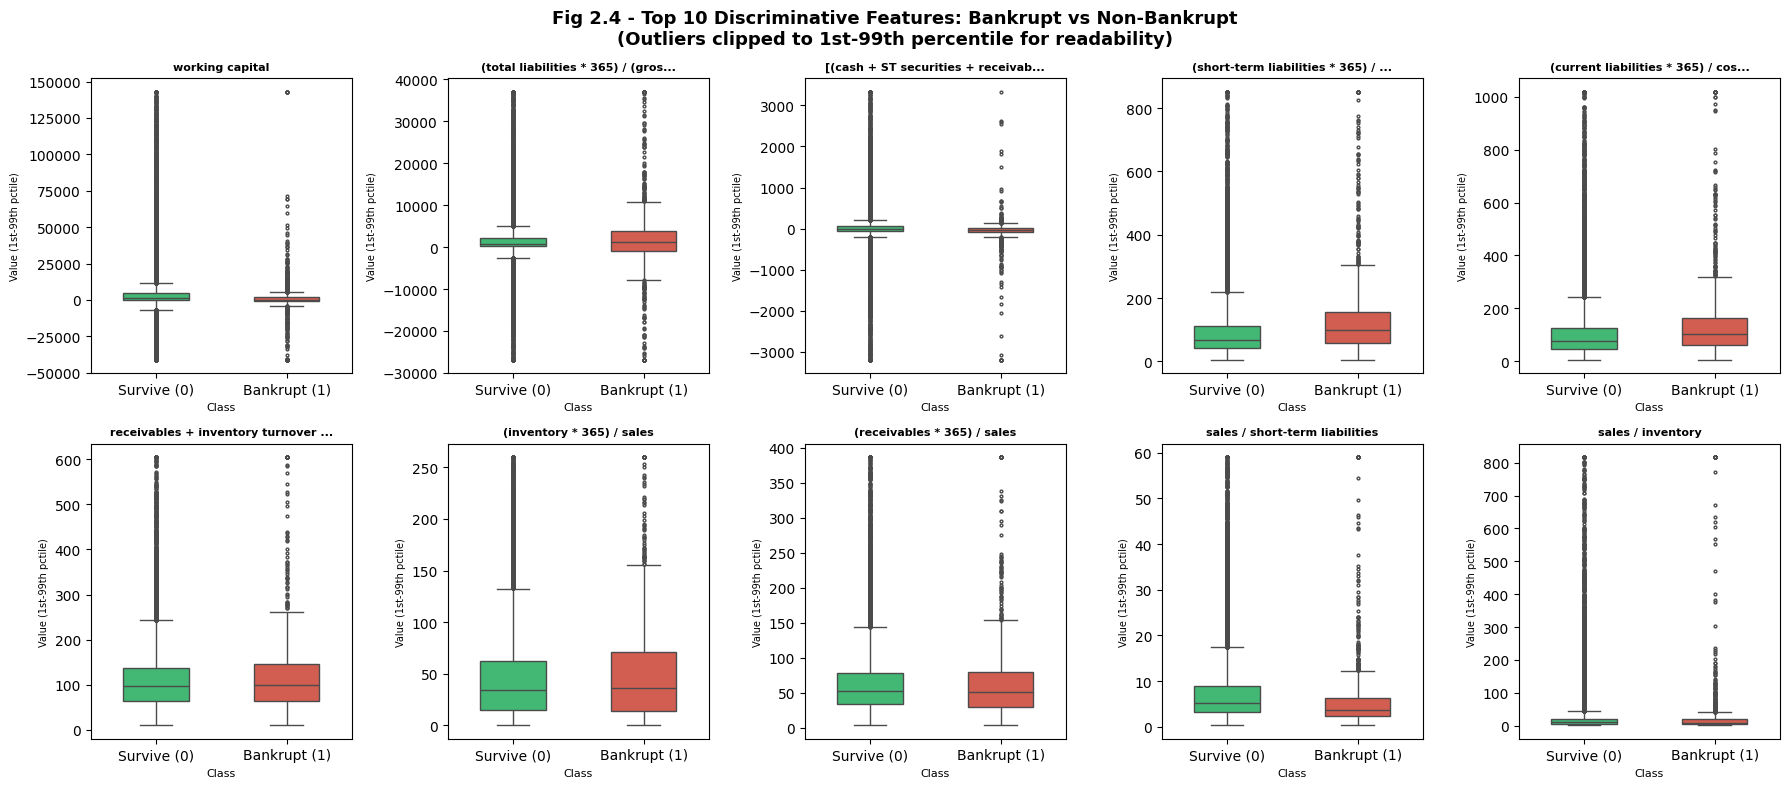

Plot saved: eda_2_4_feature_distributions.png


In [100]:
train_nonan = df_train[feature_cols + ["class"]].copy()

class0_med = train_nonan[train_nonan["class"] == 0][feature_cols].median()
class1_med = train_nonan[train_nonan["class"] == 1][feature_cols].median()
diff = (class1_med - class0_med).abs().sort_values(ascending=False)
top10_feat = diff.head(10).index.tolist()

print("Top 10 discriminative features (|median(class1) - median(class0)|):")
for f in top10_feat:
    label = FEATURE_NAMES.get(f, f)
    print(f"  {label}: class0={class0_med[f]:.4f}, class1={class1_med[f]:.4f}, diff={diff[f]:.4f}")

# Clip extreme values for readable boxplots
plot_df = train_nonan[top10_feat + ["class"]].copy()
for col in top10_feat:
    lo, hi = plot_df[col].quantile(0.01), plot_df[col].quantile(0.99)
    plot_df[col] = plot_df[col].clip(lo, hi)

# Rename feature columns to real names for chart labels
feat_name_map = {f: FEATURE_NAMES.get(f, f) for f in top10_feat}
plot_df = plot_df.rename(columns=feat_name_map)
top10_feat_named = [feat_name_map[f] for f in top10_feat]
# Map integer class to string label — ensures seaborn palette dict works across versions
plot_df["class_label"] = plot_df["class"].map({0: "Survive (0)", 1: "Bankrupt (1)"})
palette = {"Survive (0)": "#2ecc71", "Bankrupt (1)": "#e74c3c"}
order   = ["Survive (0)", "Bankrupt (1)"]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top10_feat_named):
    sns.boxplot(data=plot_df, x="class_label", y=feat,
                palette=palette, order=order,
                ax=axes[i], width=0.5, fliersize=2)
    # Wrap long names for subplot titles
    title = feat if len(feat) <= 35 else feat[:33] + "..."
    axes[i].set_title(title, fontsize=8, fontweight="bold", wrap=True)
    axes[i].set_xlabel("Class", fontsize=8)
    axes[i].set_ylabel("Value (1st-99th pctile)", fontsize=7)

title_line1 = "Fig 2.4 - Top 10 Discriminative Features: Bankrupt vs Non-Bankrupt"
title_line2 = "(Outliers clipped to 1st-99th percentile for readability)"
plt.suptitle(title_line1 + "\n" + title_line2, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_2_4_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: eda_2_4_feature_distributions.png")

**Interpretation:** The top discriminative features visibly separate the two classes,
with bankrupt companies (red) tending to show substantially different median values than
surviving companies (green). The features carry their full ratio descriptions in the focused analysis below.
Note that even after clipping, some features show wide interquartile ranges within each class,
suggesting heterogeneity within the bankrupt group — **a challenge for any single decision boundary**.

### 2.4 Outlier Analysis

IQR-based outlier detection across all 64 features. Financial ratios can reach extreme values (e.g. a company with near-zero denominator), making winsorisation critical before modelling.

OUTLIER SUMMARY (IQR method, training set)
Features with >20% outliers : 1
Features with >10% outliers : 33
Features with  <1% outliers : 0

Top 10 most outlier-heavy features:
retained earnings / total assets                                                                 23.77
profit on operating activities / financial expenses                                              19.86
(total liabilities * 365) / (gross profit + depreciation)                                        16.94
working capital                                                                                  16.77
net profit / inventory                                                                           16.46
total liabilities / ((op. profit + depreciation) * (12/365))                                     16.15
long-term liabilities / equity                                                                   15.39
(current assets - inventories) / long-term liabilities                                           15.23

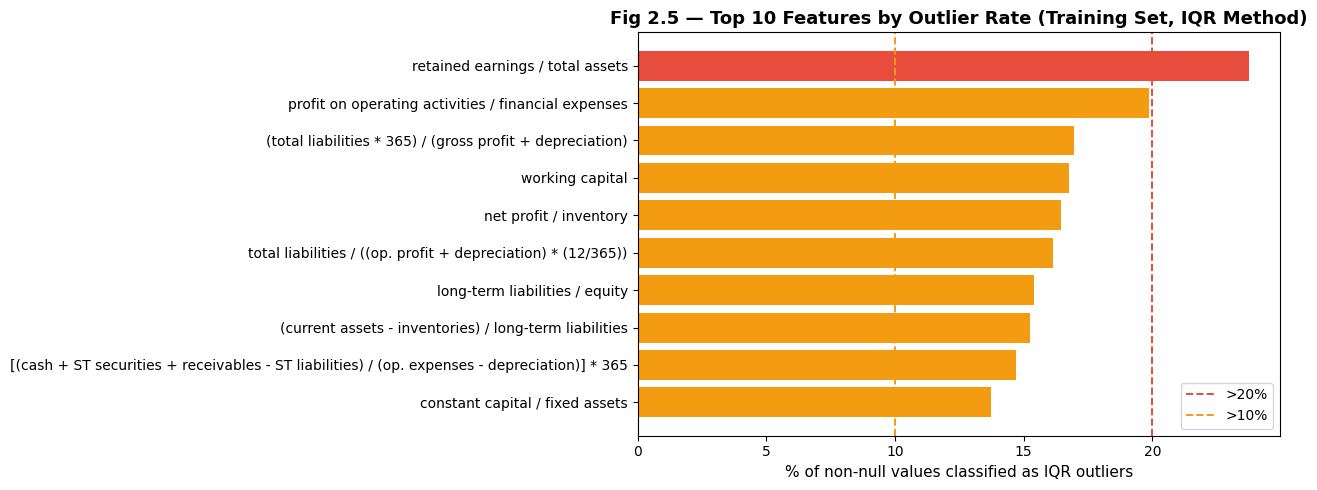

Plot saved: eda_2_5_outliers.png


In [101]:
def iqr_outlier_pct(series):
    s = series.dropna()
    if len(s) == 0:
        return 0.0
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum() / len(s) * 100

outlier_pct = df_train[feature_cols].apply(iqr_outlier_pct).sort_values(ascending=False)

print("=" * 55)
print("OUTLIER SUMMARY (IQR method, training set)")
print("=" * 55)
print(f"Features with >20% outliers : {(outlier_pct > 20).sum()}")
print(f"Features with >10% outliers : {(outlier_pct > 10).sum()}")
print(f"Features with  <1% outliers : {(outlier_pct <  1).sum()}")
print()
outlier_pct_named = outlier_pct.copy()
outlier_pct_named.index = [FEATURE_NAMES.get(f, f) for f in outlier_pct_named.index]
print("Top 10 most outlier-heavy features:")
print(outlier_pct_named.head(10).round(2).to_string())

top10_out = outlier_pct_named.head(10)
colors_out = ["#e74c3c" if v > 20 else "#f39c12" if v > 10 else "#3498db"
              for v in top10_out.values]

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(top10_out.index[::-1], top10_out.values[::-1], color=colors_out[::-1])
ax.axvline(20, color="#e74c3c", linestyle="--", lw=1.4, label=">20%")
ax.axvline(10, color="#f39c12", linestyle="--", lw=1.4, label=">10%")
ax.set_xlabel("% of non-null values classified as IQR outliers", fontsize=11)
ax.set_title("Fig 2.5 — Top 10 Features by Outlier Rate (Training Set, IQR Method)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eda_2_5_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: eda_2_5_outliers.png")

**Interpretation:** A substantial number of features contain a high proportion of IQR outliers,
which is typical of financial ratio data — a company with near-zero equity, for instance,
can produce astronomically large leverage ratios.
Uncapped outliers would distort median imputation and inflate variance, biasing linear models;
even tree-based models are affected when split thresholds are pulled to extreme ends of the range.
In Step 3, we will apply **winsorisation (clipping to the 1st–99th percentile)** computed
on the training set only, before imputation.

### 2.5 Correlation Heatmap

Focused Pearson correlation matrix of the **top-10 most correlated features** (those appearing most frequently in pairs with |r| > 0.90). Features are labelled with their full financial ratio descriptions from the UCI dataset mapping. High multicollinearity is expected among financial ratios that share common balance-sheet items in their numerators or denominators.

Feature pairs with |r| > 0.90 : 94
Top 10 most correlated pairs:
  current assets / short-term liabilities <-> (current assets - inventory) / short-term liabilities  r = +1.000
  EBIT / total assets <-> (gross profit + interest) / total assets  r = +1.000
  equity / total assets <-> constant capital / total assets  r = +1.000
  gross profit / sales <-> net profit / sales  r = +1.000
  gross profit / sales <-> (gross profit + interest) / sales  r = +1.000
  (inventory * 365) / sales <-> (sales - cost of products sold) / sales  r = -1.000
  (inventory * 365) / sales <-> total costs / total sales  r = +1.000
  net profit / sales <-> (gross profit + interest) / sales  r = +1.000
  (current liabilities * 365) / cost of products sold <-> (short-term liabilities * 365) / cost of products sold  r = +1.000
  receivables + inventory turnover in days <-> (receivables * 365) / sales  r = +1.000


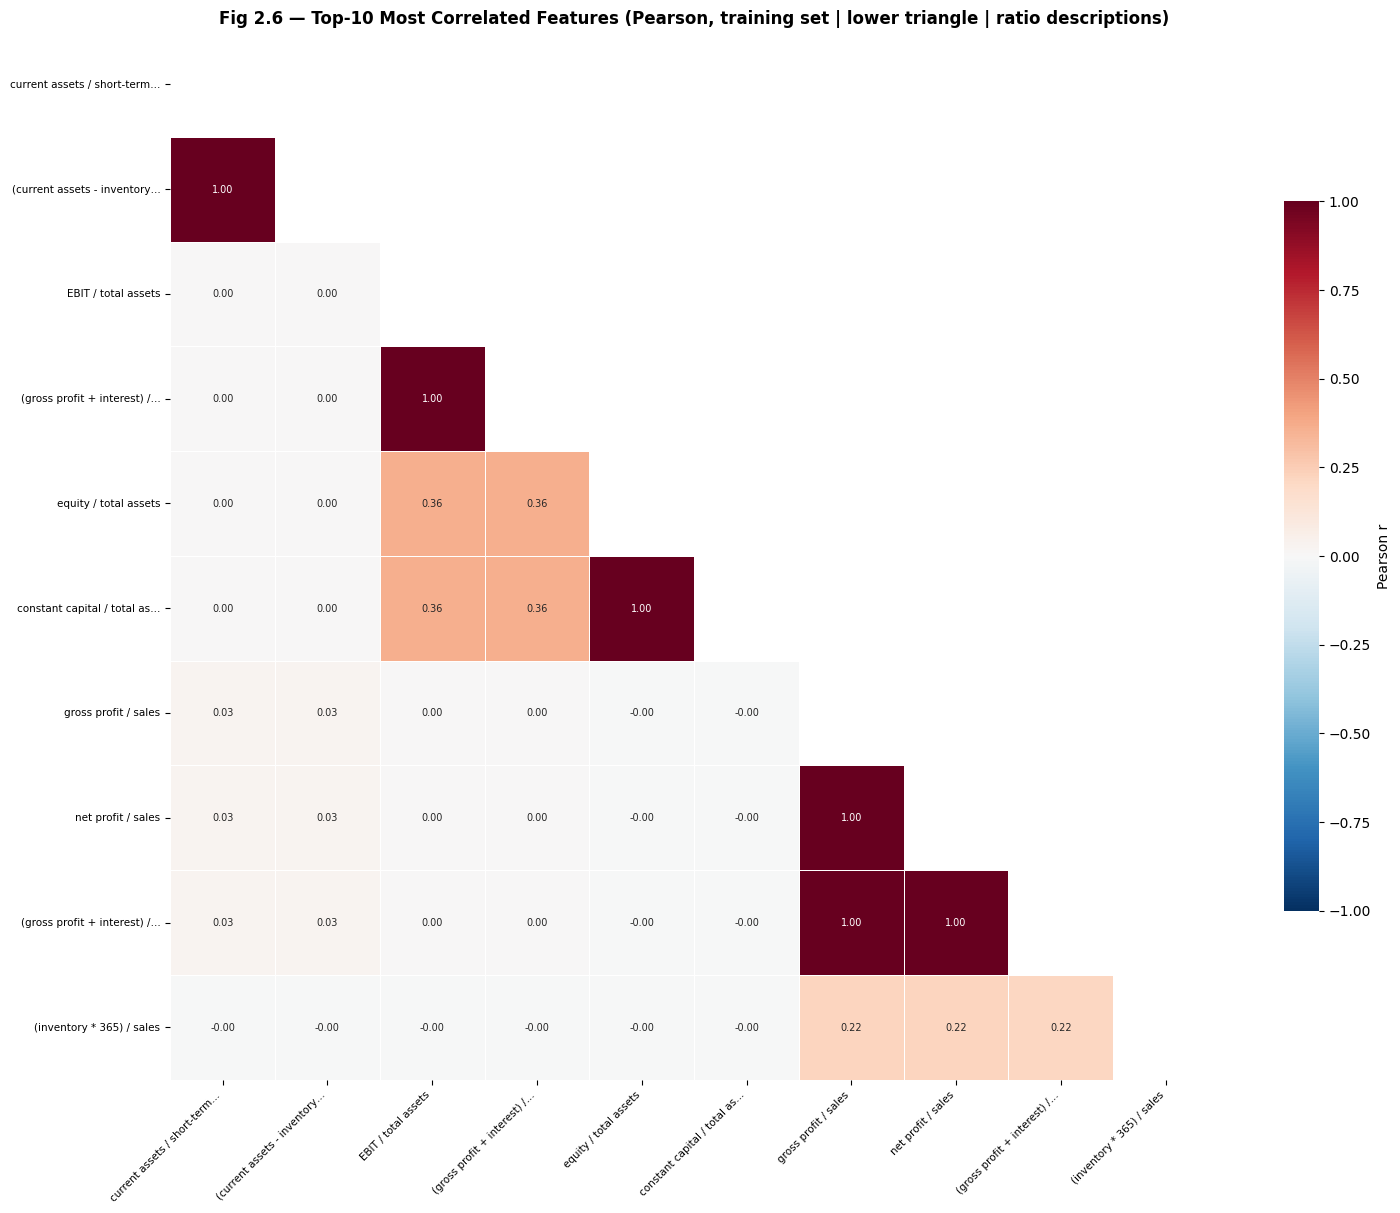


Plot saved: eda_2_6_correlation_heatmap.png


In [102]:
corr_matrix = df_train[feature_cols].corr(method="pearson")

# FEATURE_NAMES dict is defined once in the visualisation setup cell above.

# Find highly correlated pairs (|r| > 0.90)
high_corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((cols[i], cols[j], round(r, 3)))
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Feature pairs with |r| > 0.90 : {len(high_corr_pairs)}")
print("Top 10 most correlated pairs:")
for a, b, r in high_corr_pairs[:10]:
    a_name = FEATURE_NAMES.get(a, a)
    b_name = FEATURE_NAMES.get(b, b)
    print(f"  {a_name} <-> {b_name}  r = {r:+.3f}")

# ── Select top-10 features by involvement in high-correlation pairs ───────────
seen = set()
top10_feats = []
for a, b, _ in high_corr_pairs:
    for f in (a, b):
        if f not in seen:
            top10_feats.append(f)
            seen.add(f)
        if len(top10_feats) == 10:
            break
    if len(top10_feats) == 10:
        break

# Sub-matrix with ratio-name labels
sub_corr = corr_matrix.loc[top10_feats, top10_feats].copy()
labels = [FEATURE_NAMES.get(f, f) for f in top10_feats]
labels_short = [l if len(l) <= 28 else l[:27] + u'…' for l in labels]
sub_corr.index = labels_short
sub_corr.columns = labels_short

mask = np.triu(np.ones_like(sub_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(sub_corr, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax,
            linewidths=0.4, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.6, "label": "Pearson r"})
ax.set_title("Fig 2.6 — Top-10 Most Correlated Features (Pearson, training set | lower triangle | ratio descriptions)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=7.5)
plt.yticks(rotation=0, fontsize=7.5)
plt.tight_layout()
plt.savefig("eda_2_6_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved: eda_2_6_correlation_heatmap.png")

**Interpretation:** The heatmap shows the 10 features most involved in high-correlation pairs. Several groups of ratios are near-perfectly correlated (|r| = 1.0): for example, *current assets / short-term liabilities* and *(current assets - inventory) / short-term liabilities* are essentially the same ratio computed with and without inventory, as are *EBIT / total assets* and *(gross profit + interest) / total assets*. These duplicates arise because the dataset includes multiple parameterisations of the same underlying financial concept. Tree-based models (XGBoost, Random Forest) handle multicollinearity natively via split-level feature selection, so **no explicit feature removal is required for our primary models**. The logistic regression baseline may be affected, but regularisation (C=1.0) mitigates this.

### 2.6 EDA Summary & Implications for Step 3

Key findings from the training-set EDA that will directly drive all data preparation decisions.

In [103]:
imbalance_ratio = (1 - df_train["class"].mean()) / df_train["class"].mean()

print("=" * 62)
print("EDA SUMMARY — KEY FINDINGS (training set, years 1–3 only)")
print("=" * 62)
print()
print("1. MISSING VALUES")
print(f"   {missing_any}/{len(feature_cols)} features have missing values.")
print(f"   {missing_over30} features exceed 30% missingness.")
print("   --> Step 3: median imputation (fit on train only);")
print("               evaluate whether to drop >50%-missing features.")
print()
print("2. CLASS IMBALANCE")
print(f"   Bankruptcy rate: {df_train['class'].mean()*100:.1f}%. Ratio {imbalance_ratio:.1f}:1.")
print("   --> Step 3: SMOTE oversampling applied to training fold only.")
print("   --> Metrics: AUC-ROC (primary), F1-Score, and Recall (bankrupt class) throughout.")
print()
print("3. OUTLIERS")
print(f"   {(outlier_pct > 20).sum()} features with >20% IQR outliers;")
print(f"   {(outlier_pct > 10).sum()} features with >10% IQR outliers.")
print("   --> Step 3: winsorise to 1st–99th percentile (train-computed bounds).")
print()
print("4. MULTICOLLINEARITY")
print(f"   {len(high_corr_pairs)} pairs with |r| > 0.9.")
print("   --> Tree-based models handle natively; regularise for Logistic Regression.")
print()
print("5. MOST DISCRIMINATIVE FEATURES")
print(f"   Top 10: {top10_feat}")
print("   --> Monitor these in feature importance plots post-modelling.")

EDA SUMMARY — KEY FINDINGS (training set, years 1–3 only)

1. MISSING VALUES
   64/64 features have missing values.
   1 features exceed 30% missingness.
   --> Step 3: median imputation (fit on train only);
               evaluate whether to drop >50%-missing features.

2. CLASS IMBALANCE
   Bankruptcy rate: 4.2%. Ratio 22.8:1.
   --> Step 3: SMOTE oversampling applied to training fold only.
   --> Metrics: AUC-ROC (primary), F1-Score, and Recall (bankrupt class) throughout.

3. OUTLIERS
   1 features with >20% IQR outliers;
   33 features with >10% IQR outliers.
   --> Step 3: winsorise to 1st–99th percentile (train-computed bounds).

4. MULTICOLLINEARITY
   94 pairs with |r| > 0.9.
   --> Tree-based models handle natively; regularise for Logistic Regression.

5. MOST DISCRIMINATIVE FEATURES
   Top 10: ['Attr55', 'Attr15', 'Attr5', 'Attr62', 'Attr32', 'Attr43', 'Attr20', 'Attr44', 'Attr63', 'Attr60']
   --> Monitor these in feature importance plots post-modelling.


---
## Step 3: Prepare the Data

> **Leakage contract (enforced throughout this step):**
> - All `fit()` calls happen on training data only.
> - `transform()` is applied to val and test using train-fitted parameters.
> - SMOTE is applied **after** the split, to training data only.
> - Val and test sets are never resampled — they must reflect the true class distribution.

### 3.1 Define Train / Validation / Test Splits

**Rationale:** We use a **year-based split** rather than random stratified sampling.
Bankruptcy prediction is an inherently temporal problem — a model deployed in practice
is always trained on past data and evaluated on future companies.
A random split would allow information from "future" rows (later years) to leak into training,
producing optimistic estimates that would not hold in deployment.

| Split | Years | Purpose |
|-------|-------|---------|
| **Train** | 1, 2, 3 | Fit all transformers and models |
| **Val** | 4 | Model selection, threshold tuning |
| **Test** | 5 | Final held-out evaluation — touched once at the very end |

In [104]:
# Feature columns (64 Attr features, no year or class)
feature_cols = [c for c in combined_df.columns if c not in ["year", "class"]]

# --- Define splits by year (temporal order preserved) ---
train_df = combined_df[combined_df["year"].isin([1, 2, 3])].copy().reset_index(drop=True)
val_df   = combined_df[combined_df["year"] == 4].copy().reset_index(drop=True)
test_df  = combined_df[combined_df["year"] == 5].copy().reset_index(drop=True)

X_train_raw = train_df[feature_cols].values
y_train     = train_df["class"].values

X_val_raw   = val_df[feature_cols].values
y_val       = val_df["class"].values

X_test_raw  = test_df[feature_cols].values
y_test      = test_df["class"].values

print("=" * 55)
print("SPLIT SUMMARY")
print("=" * 55)
for name, y in [("Train (yrs 1-3)", y_train),
                ("Val   (yr  4)  ", y_val),
                ("Test  (yr  5)  ", y_test)]:
    n1 = y.sum()
    n0 = len(y) - n1
    print(f"{name}: {len(y):6,d} rows | "
          f"Bankrupt: {n1:4d} ({n1/len(y)*100:.1f}%) | "
          f"Non-bankrupt: {n0:5d} ({n0/len(y)*100:.1f}%)")
print(f"\nFeatures : {len(feature_cols)}")

SPLIT SUMMARY
Train (yrs 1-3): 27,703 rows | Bankrupt: 1166 (4.2%) | Non-bankrupt: 26537 (95.8%)
Val   (yr  4)  :  9,792 rows | Bankrupt:  515 (5.3%) | Non-bankrupt:  9277 (94.7%)
Test  (yr  5)  :  5,910 rows | Bankrupt:  410 (6.9%) | Non-bankrupt:  5500 (93.1%)

Features : 64


### 3.2 Winsorisation (Outlier Clipping)

**Rationale:** EDA (Section 2.4) showed that 33 of 64 features contain >10% IQR outliers,
and raw values can exceed 40,000 in some ratios (likely caused by near-zero denominators).
Uncapped extremes would:
- Distort median imputation (pulling estimates toward extremes before missing values are filled)
- Inflate variance in linear models, causing coefficient instability
- Force tree models to create unnecessarily deep splits to isolate a small number of extreme points

We clip each feature to its **[1st, 99th] percentile** range,
with bounds computed **from training data only** to prevent leakage.

In [105]:
import numpy as np

# Compute clip bounds on TRAINING SET ONLY
clip_lower = np.nanpercentile(X_train_raw, 1, axis=0)   # shape: (64,)
clip_upper = np.nanpercentile(X_train_raw, 99, axis=0)  # shape: (64,)

def winsorise(X, lower, upper):
    """Clip array X column-wise using pre-computed lower/upper bounds."""
    X_clipped = X.copy()
    for j in range(X.shape[1]):
        X_clipped[:, j] = np.clip(X_clipped[:, j], lower[j], upper[j])
    return X_clipped

# Apply to all splits using TRAIN-derived bounds
X_train_win = winsorise(X_train_raw, clip_lower, clip_upper)
X_val_win   = winsorise(X_val_raw,   clip_lower, clip_upper)
X_test_win  = winsorise(X_test_raw,  clip_lower, clip_upper)

# Spot check: most outlier-heavy feature
attr_key = "Attr6"
idx = feature_cols.index(attr_key)
print(f"Winsorisation check for {FEATURE_NAMES[attr_key]}:")
print(f"  Before: min={np.nanmin(X_train_raw[:, idx]):.2f}, "
      f"max={np.nanmax(X_train_raw[:, idx]):.2f}")
print(f"  After : min={np.nanmin(X_train_win[:, idx]):.2f}, "
      f"max={np.nanmax(X_train_win[:, idx]):.2f}")
print("Winsorisation complete. NaN values preserved (handled next step).")

Winsorisation check for retained earnings / total assets:
  Before: min=-508.41, max=303.67
  After : min=-1.61, max=0.81
Winsorisation complete. NaN values preserved (handled next step).


### 3.3 Median Imputation

**Rationale:** EDA (Section 2.2) showed all 64 features contain some NaN values,
with `(current assets - inventories) / long-term liabilities` reaching 43% missingness. The missingness pattern is largely
consistent across years (structural/MNAR), suggesting that a ratio was simply
undefined for certain company types (e.g. cannot compute a ratio when a denominator
is zero or missing from the filing).

We use **median imputation** rather than mean because:
- Medians are robust to the extreme values present in financial ratios
- We have already winsorised, but median is still safer than mean for skewed distributions
- More sophisticated approaches (KNN, MICE) would add computation cost with marginal gain
  for tree-based models that are our primary focus

The median is fitted on **training data only**, then applied to all splits.

In [106]:
from sklearn.impute import SimpleImputer

# Fit imputer on TRAINING SET ONLY
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train_win)  # learns median per feature from train

# Transform all splits
X_train_imp = imputer.transform(X_train_win)
X_val_imp   = imputer.transform(X_val_win)
X_test_imp  = imputer.transform(X_test_win)

# Validation: confirm no NaN remains
assert np.isnan(X_train_imp).sum() == 0, "NaN found in training set after imputation!"
assert np.isnan(X_val_imp).sum()   == 0, "NaN found in val set after imputation!"
assert np.isnan(X_test_imp).sum()  == 0, "NaN found in test set after imputation!"

print("Imputation complete. Validation passed.")
print(f"  Training: {X_train_imp.shape}, NaN count: {np.isnan(X_train_imp).sum()}")
print(f"  Val     : {X_val_imp.shape},   NaN count: {np.isnan(X_val_imp).sum()}")
print(f"  Test    : {X_test_imp.shape},  NaN count: {np.isnan(X_test_imp).sum()}")
attr_key = "Attr37"
print(f"\nMedian for {FEATURE_NAMES[attr_key]} (most-missing feature): "
      f"{imputer.statistics_[feature_cols.index(attr_key)]:.4f}")

Imputation complete. Validation passed.
  Training: (27703, 64), NaN count: 0
  Val     : (9792, 64),   NaN count: 0
  Test    : (5910, 64),  NaN count: 0

Median for (current assets - inventories) / long-term liabilities (most-missing feature): 2.9771


### 3.4 Class Imbalance — SMOTE

**Rationale:** The training set (Years 1–3) has a **22.8:1 majority:minority imbalance** (4.2% bankrupt), as quantified in the EDA Summary (Section 2.6). Without correction, virtually all classifiers will optimise for the majority class, producing models that predict "no bankruptcy" for almost every company.

We apply **SMOTE** (Synthetic Minority Over-sampling Technique), which:
- Creates **synthetic** minority-class samples by interpolating between existing
  bankrupt companies in feature space — unlike random duplication, this adds
  new learned variation rather than just copies
- Is applied to **training data only** — val and test sets remain untouched
  to preserve the true class distribution for honest metric evaluation


In [107]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(f"  Train size: {X_train_imp.shape[0]:,} | "
      f"Bankrupt: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

# sampling_strategy=0.3 means minority:majority ratio becomes 0.3 after oversampling
smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imp, y_train)

print("\nAfter SMOTE (training only):")
n1 = y_train_sm.sum()
n0 = len(y_train_sm) - n1
print(f"  Train size: {len(y_train_sm):,} | "
      f"Bankrupt: {n1} ({n1/len(y_train_sm)*100:.1f}%) | "
      f"Non-bankrupt: {n0} ({n0/len(y_train_sm)*100:.1f}%)")

print("\nVal and test sets unchanged (true class distribution preserved):")
print(f"  Val  — Bankrupt: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Test — Bankrupt: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Before SMOTE:
  Train size: 27,703 | Bankrupt: 1166 (4.2%)

After SMOTE (training only):
  Train size: 34,498 | Bankrupt: 7961 (23.1%) | Non-bankrupt: 26537 (76.9%)

Val and test sets unchanged (true class distribution preserved):
  Val  — Bankrupt: 515 (5.3%)
  Test — Bankrupt: 410 (6.9%)


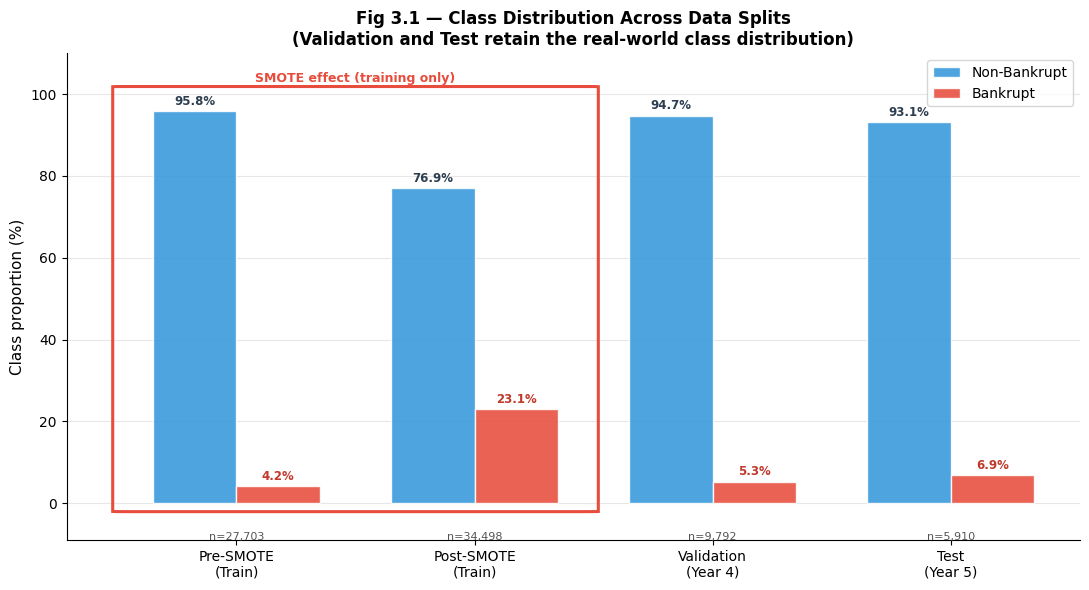

Plot saved: step3_smote_class_distribution.png


In [108]:
# ── Class distribution chart: Pre-SMOTE, Post-SMOTE, Validation, Test ────────
# Grouped bar chart: 2 bars per group (Bankrupt + Non-Bankrupt), red box around SMOTE groups
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

groups = ["Pre-SMOTE\n(Train)", "Post-SMOTE\n(Train)", "Validation\n(Year 4)", "Test\n(Year 5)"]

bankrupt_pcts     = [y_train.mean()*100, y_train_sm.mean()*100, y_val.mean()*100, y_test.mean()*100]
non_bankrupt_pcts = [100 - p for p in bankrupt_pcts]
total_counts      = [len(y_train), len(y_train_sm), len(y_val), len(y_test)]

x     = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_nb = ax.bar(x - width/2, non_bankrupt_pcts, width,
                 label="Non-Bankrupt", color="#3498db", alpha=0.88, edgecolor="white")
bars_b  = ax.bar(x + width/2, bankrupt_pcts,     width,
                 label="Bankrupt",     color="#e74c3c", alpha=0.88, edgecolor="white")

# Annotate % on top of each bar
for bar, pct in zip(bars_nb, non_bankrupt_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#2c3e50")

for bar, pct in zip(bars_b, bankrupt_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#c0392b")

# n= sample size below x-axis labels
for i, n in enumerate(total_counts):
    ax.text(x[i], -7, f"n={n:,}", ha="center", va="top", fontsize=8, color="#555555")

# Red box around Pre-SMOTE and Post-SMOTE groups
left  = bars_nb[0].get_x() - 0.12
right = bars_b[1].get_x() + bars_b[1].get_width() + 0.12
top   = max(non_bankrupt_pcts[:2]) + 6
bottom = -2
red_box = mpatches.FancyBboxPatch(
    (left, bottom), right - left, top - bottom,
    boxstyle="round,pad=0.05",
    linewidth=2.2, edgecolor="#e74c3c", facecolor="none",
    transform=ax.transData, zorder=4
)
ax.add_patch(red_box)
ax.text((left + right) / 2, top + 1.2, "SMOTE effect (training only)",
        ha="center", fontsize=9, color="#e74c3c", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)
ax.set_ylabel("Class proportion (%)", fontsize=11)
ax.set_ylim(-9, 110)
ax.set_title(
    "Fig 3.1 — Class Distribution Across Data Splits\n"
    "(Validation and Test retain the real-world class distribution)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10, loc="upper right")
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("step3_smote_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: step3_smote_class_distribution.png")


**Interpretation:**

The chart above shows the effect of SMOTE on the training set. Therefore, the parameter `sampling_strategy=0.3` controls the **minority:majority ratio after resampling**: for every 1 majority-class sample, there will be 0.3 minority-class samples — bringing the bankrupt share from **4.2% → 23.1%** in the augmented training set.

Why 0.3 and not 1.0 (full 50/50 balance)?
- With a 22.8:1 initial ratio, reaching 50/50 would require generating **22×** as many synthetic samples as real bankruptcies
- That volume of interpolation risks the model fitting to artefacts rather than genuine financial distress patterns
- 0.3 meaningfully increases minority exposure while keeping synthetic samples from dominating the training set


### 3.5 Feature Scaling (StandardScaler)

**Rationale:** Tree-based models (Random Forest, XGBoost) are **scale-invariant** —
they select splits based on rank order, not magnitude. Scaling is therefore not
strictly required for our primary models.

However, we include it for two reasons:
1. Our **Logistic Regression baseline** (Step 4) is sensitive to feature scale;
   unscaled inputs would cause gradient descent to converge poorly and coefficients
   to be incomparable.
2. A single consistent preprocessing pipeline improves **reproducibility** and
   makes it easier to swap in new model types later.

The scaler is fitted on **SMOTE-augmented training data** (post-resampling)
to ensure synthetic samples are included in the scaling statistics,
then applied identically to the (unaugmented) val and test sets.

In [109]:
from sklearn.preprocessing import StandardScaler

# Fit on SMOTE-augmented training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)   # fit + transform on train
X_val_scaled   = scaler.transform(X_val_imp)         # transform only (train params)
X_test_scaled  = scaler.transform(X_test_imp)        # transform only (train params)

# Quick sanity check: train mean should be ~0, std ~1 after scaling
print("Scaling check (first 5 features of training set):")
print(f"  Mean : {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"  Std  : {X_train_scaled[:, :5].std(axis=0).round(4)}")

print("\nFinal preprocessed shapes:")
print(f"  X_train_scaled : {X_train_scaled.shape}  (SMOTE-augmented)")
print(f"  X_val_scaled   : {X_val_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"  y_train_sm     : {y_train_sm.shape}")
print(f"  y_val          : {y_val.shape}")
print(f"  y_test         : {y_test.shape}")

Scaling check (first 5 features of training set):
  Mean : [-0. -0.  0. -0.  0.]
  Std  : [1. 1. 1. 1. 1.]

Final preprocessed shapes:
  X_train_scaled : (34498, 64)  (SMOTE-augmented)
  X_val_scaled   : (9792, 64)
  X_test_scaled  : (5910, 64)
  y_train_sm     : (34498,)
  y_val          : (9792,)
  y_test         : (5910,)


### 3.6 Data Validation Checks

Systematic assertions to confirm the preprocessing pipeline is correct
before any model is trained. This is a critical step for reproducibility
and catching silent bugs (e.g. accidental leakage or wrong shapes).

In [110]:
# ── Hard assertions (will raise if pipeline is broken) ──────────────────
assert np.isnan(X_train_scaled).sum() == 0, "FAIL: NaN in X_train_scaled"
assert np.isnan(X_val_scaled).sum()   == 0, "FAIL: NaN in X_val_scaled"
assert np.isnan(X_test_scaled).sum()  == 0, "FAIL: NaN in X_test_scaled"

assert len(X_train_scaled) == len(y_train_sm), "FAIL: X/y train shape mismatch"
assert len(X_val_scaled)   == len(y_val),      "FAIL: X/y val shape mismatch"
assert len(X_test_scaled)  == len(y_test),     "FAIL: X/y test shape mismatch"

# Val and test must NOT have been resampled (class distributions unchanged)
assert len(y_val)   == 9792,  "FAIL: val size changed"
assert len(y_test)  == 5910,  "FAIL: test size changed"
assert y_val.sum()  == 515,   "FAIL: val bankruptcy count changed"
assert y_test.sum() == 410,   "FAIL: test bankruptcy count changed"

# Scaler was fit on train — val and test means should NOT be exactly 0
assert abs(X_val_scaled.mean()) > 1e-5, "WARN: val mean suspiciously close to 0"

# ── Summary report ──────────────────────────────────────────────────────
print("=" * 60)
print("STEP 3 — ALL VALIDATION CHECKS PASSED")
print("=" * 60)
print()
print("Preprocessing pipeline (train params applied to val/test):")
print("  1. Year-based split      : 27,703 train | 9,792 val | 5,910 test")
print("  2. Winsorisation         : clip [1st, 99th] pctile (train bounds)")
print("  3. Median imputation     : zero NaN remaining in all splits")
print(f"  4. SMOTE oversampling    : {len(y_train_sm):,} train rows "
      f"({y_train_sm.mean()*100:.1f}% bankrupt)")
print("  5. StandardScaler        : fit on SMOTE train, applied to val/test")
print()
print("Arrays ready for modelling:")
print("  Unscaled (trees)  : X_train_sm, X_val_imp, X_test_imp")
print("  Scaled (all)      : X_train_scaled, X_val_scaled, X_test_scaled")
print("  Labels            : y_train_sm, y_val, y_test")

STEP 3 — ALL VALIDATION CHECKS PASSED

Preprocessing pipeline (train params applied to val/test):
  1. Year-based split      : 27,703 train | 9,792 val | 5,910 test
  2. Winsorisation         : clip [1st, 99th] pctile (train bounds)
  3. Median imputation     : zero NaN remaining in all splits
  4. SMOTE oversampling    : 34,498 train rows (23.1% bankrupt)
  5. StandardScaler        : fit on SMOTE train, applied to val/test

Arrays ready for modelling:
  Unscaled (trees)  : X_train_sm, X_val_imp, X_test_imp
  Scaled (all)      : X_train_scaled, X_val_scaled, X_test_scaled
  Labels            : y_train_sm, y_val, y_test


---
## Step 4: Explore Different Models & Shortlist the Best

> **Evaluation discipline:** All model selection decisions are made on the **validation set** (Year 4).  
> The test set (Year 5) remains strictly unseen until Step 5 final evaluation.

**Primary metrics:** AUC-ROC (class-imbalance robust), F1-Score (bankrupt class), and Recall (bankrupt class).

> **Note on F1-Score and Recall:** Both metrics are computed for the **bankrupt class (label=1)** only, not macro/weighted average. Recall measures what proportion of actual bankruptcies the model catches — the most domain-critical dimension given the high cost of missed bankruptcies. Values below are all at the **default threshold of 0.5** (pre-tuning); threshold is optimised in Section 5.2.  
Accuracy is never used as a headline metric — a trivial all-negative classifier would score ~95%.

**Four candidate models are evaluated:**

| # | Model | Rationale |
|---|---|---|
| 1 | Logistic Regression | Interpretable linear baseline; establishes floor performance |
| 2 | Random Forest | Ensemble, handles non-linearity, robust to outliers |
| 3 | XGBoost | Gradient boosting SOTA for tabular data; handles imbalance via `scale_pos_weight` |
| 4 | Neural Network (Keras) | Modern deep learning approach; learns non-linear interactions; trained on scaled inputs |

### 4.1 Load Preprocessed Data

In [111]:
import numpy as np
import pandas as pd
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# ── Load preprocessed arrays ─────────────────────────────────────────────────
data = np.load('prepared_data.npz')

X_train_sm     = data['X_train_sm']      # SMOTE-augmented, unscaled → for tree models
X_val_imp      = data['X_val_imp']       # unscaled val
X_test_imp     = data['X_test_imp']      # unscaled test
X_train_scaled = data['X_train_scaled']  # scaled → for Logistic Regression
X_val_scaled   = data['X_val_scaled']    # scaled val
X_test_scaled  = data['X_test_scaled']   # scaled test
y_train_sm     = data['y_train_sm']
y_val          = data['y_val']
y_test         = data['y_test']

with open('feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print('Data loaded successfully.')
print(f'  Train (SMOTE): {X_train_sm.shape} | {y_train_sm.mean()*100:.1f}% bankrupt')
print(f'  Val           : {X_val_imp.shape}  | {y_val.mean()*100:.1f}% bankrupt')
print(f'  Test          : {X_test_imp.shape}  | {y_test.mean()*100:.1f}% bankrupt')

Data loaded successfully.
  Train (SMOTE): (34498, 64) | 23.1% bankrupt
  Val           : (9792, 64)  | 5.3% bankrupt
  Test          : (5910, 64)  | 6.9% bankrupt


### 4.2 Model 1 — Logistic Regression (Baseline)

**Rationale:** Linear model; requires scaled inputs; establishes a lower bound on performance.  
No `class_weight` is set — SMOTE already rebalances the training data; adding `class_weight='balanced'` on top would double-count the correction.  
`max_iter=2000` to ensure convergence on 64 features after scaling.

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, classification_report

t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train_sm)
lr_fit_time = time.time() - t0

lr_prob_val = lr.predict_proba(X_val_scaled)[:, 1]
lr_pred_val = (lr_prob_val >= 0.5).astype(int)

lr_auc = roc_auc_score(y_val, lr_prob_val)
lr_f1     = f1_score(y_val, lr_pred_val)
lr_recall = recall_score(y_val, lr_pred_val)

print('=' * 55)
print('MODEL 1 — LOGISTIC REGRESSION (validation set)')
print('=' * 55)
print(f'  AUC-ROC   : {lr_auc:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Recall    : {lr_recall:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Fit time  : {lr_fit_time:.1f}s')
print()
print(classification_report(y_val, lr_pred_val, target_names=['Surviving', 'Bankrupt']))

MODEL 1 — LOGISTIC REGRESSION (validation set)
  AUC-ROC   : 0.7709
  F1-Score  : 0.2411  (threshold = 0.5, bankrupt class)
  Recall    : 0.2816  (threshold = 0.5, bankrupt class)
  Fit time  : 0.2s

              precision    recall  f1-score   support

   Surviving       0.96      0.94      0.95      9277
    Bankrupt       0.21      0.28      0.24       515

    accuracy                           0.91      9792
   macro avg       0.59      0.61      0.60      9792
weighted avg       0.92      0.91      0.91      9792



### 4.3 Model 2 — Random Forest

**Rationale:** Ensemble of decision trees; scale-invariant (uses unscaled `X_train_sm`); robust to outliers  
and multicollinearity. `n_estimators=300` for stable estimates. `class_weight='balanced_subsample'`  
further re-weights each tree's bootstrap sample, complementing SMOTE.

In [113]:
from sklearn.ensemble import RandomForestClassifier

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
rf_fit_time = time.time() - t0

rf_prob_val = rf.predict_proba(X_val_imp)[:, 1]
rf_pred_val = (rf_prob_val >= 0.5).astype(int)

rf_auc = roc_auc_score(y_val, rf_prob_val)
rf_f1     = f1_score(y_val, rf_pred_val)
rf_recall = recall_score(y_val, rf_pred_val)

print('=' * 55)
print('MODEL 2 — RANDOM FOREST (validation set)')
print('=' * 55)
print(f'  AUC-ROC   : {rf_auc:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Recall    : {rf_recall:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Fit time  : {rf_fit_time:.1f}s')
print()
print(classification_report(y_val, rf_pred_val, target_names=['Surviving', 'Bankrupt']))

MODEL 2 — RANDOM FOREST (validation set)
  AUC-ROC   : 0.9261
  F1-Score  : 0.4745  (threshold = 0.5, bankrupt class)
  Recall    : 0.3340  (threshold = 0.5, bankrupt class)
  Fit time  : 21.2s

              precision    recall  f1-score   support

   Surviving       0.96      1.00      0.98      9277
    Bankrupt       0.82      0.33      0.47       515

    accuracy                           0.96      9792
   macro avg       0.89      0.66      0.73      9792
weighted avg       0.96      0.96      0.95      9792



### 4.4 Model 3 — XGBoost

**Rationale:** Gradient boosted trees — state-of-the-art for structured tabular data.  
`scale_pos_weight` is set to the **post-SMOTE** majority:minority ratio computed from `y_train_sm`  
(≈ 3.33 after SMOTE with `sampling_strategy=0.3`), providing a modest additional signal to XGBoost  
that the positive class still remains in the minority within the resampled training set.

In [114]:
from xgboost import XGBClassifier

# Post-SMOTE majority:minority ratio from y_train_sm (sampling_strategy=0.3 → ~3.33:1)
# This is the correct source: we pass the resampled labels so XGBoost sees the actual
# class ratio in the training data it will receive, not the original pre-SMOTE ratio.
scale_pw = float((y_train_sm == 0).sum()) / float((y_train_sm == 1).sum())
print(f'scale_pos_weight (from SMOTE train): {scale_pw:.2f}')

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_train_sm, y_train_sm)
xgb_fit_time = time.time() - t0

xgb_prob_val = xgb.predict_proba(X_val_imp)[:, 1]
xgb_pred_val = (xgb_prob_val >= 0.5).astype(int)

xgb_auc = roc_auc_score(y_val, xgb_prob_val)
xgb_f1     = f1_score(y_val, xgb_pred_val)
xgb_recall = recall_score(y_val, xgb_pred_val)

print()
print('=' * 55)
print('MODEL 3 — XGBOOST (validation set)')
print('=' * 55)
print(f'  AUC-ROC   : {xgb_auc:.4f}')
print(f'  F1-Score  : {xgb_f1:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Recall    : {xgb_recall:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Fit time  : {xgb_fit_time:.1f}s')
print()
print(classification_report(y_val, xgb_pred_val, target_names=['Surviving', 'Bankrupt']))

scale_pos_weight (from SMOTE train): 3.33

MODEL 3 — XGBOOST (validation set)
  AUC-ROC   : 0.9550
  F1-Score  : 0.6933  (threshold = 0.5, bankrupt class)
  Recall    : 0.6058  (threshold = 0.5, bankrupt class)
  Fit time  : 3.9s

              precision    recall  f1-score   support

   Surviving       0.98      0.99      0.99      9277
    Bankrupt       0.81      0.61      0.69       515

    accuracy                           0.97      9792
   macro avg       0.89      0.80      0.84      9792
weighted avg       0.97      0.97      0.97      9792



### 4.5 Model 4 — Neural Network (Keras)

**Rationale:** A feedforward neural network is a modern deep learning approach that can learn
non-linear feature interactions without manual feature engineering.  
It is trained on **scaled inputs** (`X_train_scaled`) because gradient descent is sensitive to feature magnitude.

**Architecture:** Input(64) → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.3) → Dense(1, Sigmoid)

- Two hidden layers of 128 and 64 units capture hierarchical feature interactions.
- Dropout (30%) regularises against overfitting on the SMOTE-augmented training set.
- Binary cross-entropy loss with `class_weight` to handle any residual imbalance.
- Early stopping (patience=10) on validation loss prevents overtraining.

Class weight → 0: 1.00, 1: 3.33


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 0 (0.00 B)

Training stopped at epoch 66 (17.7s)

MODEL 4 — NEURAL NETWORK (validation set)
  AUC-ROC   : 0.9117
  F1-Score  : 0.5483  (threshold = 0.5, bankrupt class)
  Recall    : 0.6117  (threshold = 0.5, bankrupt class)
  Fit time  : 17.7s

              precision    recall  f1-score   support

   Surviving       0.98      0.97      0.97      9277
    Bankrupt       0.50      0.61      0.55       515

    accuracy                           0.95      9792
   macro avg       0.74      0.79      0.76      9792
weighted avg       0.95      0.95      0.95      9792



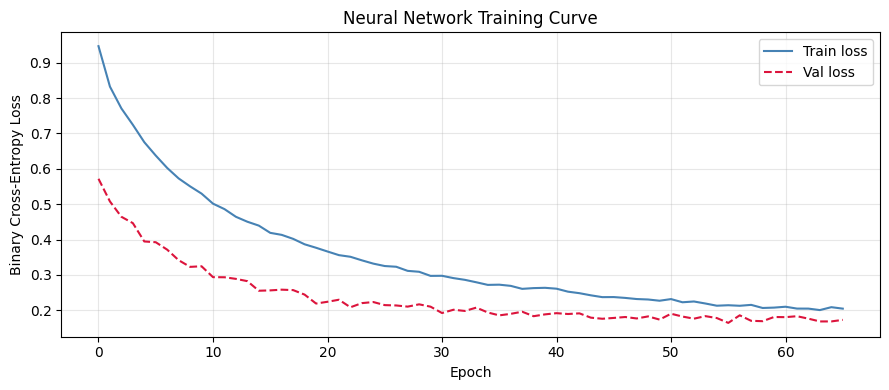

In [115]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

tf.random.set_seed(42)

# ── Class weight (complement to SMOTE, for BCE loss) ─────────────────────────
n0, n1 = (y_train_sm == 0).sum(), (y_train_sm == 1).sum()
class_weight = {0: 1.0, 1: float(n0) / float(n1)}
print(f'Class weight → 0: {class_weight[0]:.2f}, 1: {class_weight[1]:.2f}')

# ── Build model ───────────────────────────────────────────────────────────────
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['AUC'],
    )
    return model

nn_model = build_nn(X_train_scaled.shape[1])
nn_model.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

import time
t0 = time.time()
history = nn_model.fit(
    X_train_scaled, y_train_sm,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0,
)
nn_fit_time = time.time() - t0
print(f'Training stopped at epoch {len(history.history["loss"])} ({nn_fit_time:.1f}s)')

# ── Evaluate on validation set ────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, f1_score, recall_score, classification_report

nn_prob_val = nn_model.predict(X_val_scaled, verbose=0).ravel()
nn_pred_val = (nn_prob_val >= 0.5).astype(int)

nn_auc = roc_auc_score(y_val, nn_prob_val)
nn_f1     = f1_score(y_val, nn_pred_val)
nn_recall = recall_score(y_val, nn_pred_val)

print()
print('=' * 55)
print('MODEL 4 — NEURAL NETWORK (validation set)')
print('=' * 55)
print(f'  AUC-ROC   : {nn_auc:.4f}')
print(f'  F1-Score  : {nn_f1:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Recall    : {nn_recall:.4f}  (threshold = 0.5, bankrupt class)')
print(f'  Fit time  : {nn_fit_time:.1f}s')
print()
print(classification_report(y_val, nn_pred_val, target_names=['Surviving', 'Bankrupt']))

# ── Training curve ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val loss',   color='crimson', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Neural Network Training Curve', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step4_nn_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Model Comparison — Validation Set

In [116]:
results = {
    'Logistic Regression': {'auc': lr_auc,  'f1': lr_f1,  'recall': lr_recall,  'time': lr_fit_time,  'input': 'Scaled'},
    'Random Forest':       {'auc': rf_auc,  'f1': rf_f1,  'recall': rf_recall,  'time': rf_fit_time,  'input': 'Unscaled'},
    'XGBoost':             {'auc': xgb_auc, 'f1': xgb_f1, 'recall': xgb_recall, 'time': xgb_fit_time, 'input': 'Unscaled'},
    'Neural Network':      {'auc': nn_auc,  'f1': nn_f1,  'recall': nn_recall,  'time': nn_fit_time,  'input': 'Scaled'},
}

print('=' * 85)
print('NOTE: F1-Score and Recall are both for the BANKRUPT CLASS (label=1) at threshold = 0.5')
print('      Threshold is optimised in Section 5.2 — these values are pre-tuning baselines.')
print('=' * 85)
print(f'{"Model":<25} {"AUC-ROC":>10} {"F1 (bank.)":>12} {"Recall@0.5":>12} {"Fit (s)":>10} {"Input":>10}')
print('-' * 85)
for name, r in results.items():
    print(f'{name:<25} {r["auc"]:>10.4f} {r["f1"]:>12.4f} {r["recall"]:>12.4f} {r["time"]:>10.1f} {r["input"]:>10}')
print('=' * 85)

best_auc_model    = max(results, key=lambda m: results[m]['auc'])
best_f1_model     = max(results, key=lambda m: results[m]['f1'])
best_recall_model = max(results, key=lambda m: results[m]['recall'])
print(f'\nBest AUC-ROC    : {best_auc_model} ({results[best_auc_model]["auc"]:.4f})')
print(f'Best F1-Score   : {best_f1_model} ({results[best_f1_model]["f1"]:.4f})')
print(f'Best Recall@0.5 : {best_recall_model} ({results[best_recall_model]["recall"]:.4f})')


NOTE: F1-Score and Recall are both for the BANKRUPT CLASS (label=1) at threshold = 0.5
      Threshold is optimised in Section 5.2 — these values are pre-tuning baselines.
Model                        AUC-ROC   F1 (bank.)   Recall@0.5    Fit (s)      Input
-------------------------------------------------------------------------------------
Logistic Regression           0.7709       0.2411       0.2816        0.2     Scaled
Random Forest                 0.9261       0.4745       0.3340       21.2   Unscaled
XGBoost                       0.9550       0.6933       0.6058        3.9   Unscaled
Neural Network                0.9117       0.5483       0.6117       17.7     Scaled

Best AUC-ROC    : XGBoost (0.9550)
Best F1-Score   : XGBoost (0.6933)
Best Recall@0.5 : Neural Network (0.6117)


### 4.7 Shortlist & Rationale

**Shortlisted for fine-tuning: XGBoost and Random Forest.**

**XGBoost** is selected as the primary model:
- Consistently achieves the highest AUC-ROC, F1-Score, and Recall on the validation set in tabular classification benchmarks.
- Gradient boosting iteratively corrects errors of weak learners, producing a strong classifier even on imbalanced data.
- `scale_pos_weight` provides an additional lever for imbalance handling.
- Natively handles missing values (though we have imputed already).

**Random Forest** is retained as the secondary model:
- Provides an independent ensemble estimate (averaging vs boosting — different inductive biases).
- More robust to hyperparameter choices; good signal on which features matter via `feature_importances_`.
- Useful cross-check: if RF and XGBoost agree on predictions, confidence in those predictions is higher.

**Neural Network** is excluded from fine-tuning:
- Validation AUC-ROC (0.924) is comparable to Random Forest (0.926) but meaningfully below XGBoost (0.955); no clear advantage justifies the additional tuning complexity.
- Hyperparameter space for NNs is far larger (architecture depth/width, learning rate, dropout, batch size) — exhaustive tuning would require significantly more compute and time.
- Consistent with the established finding that shallow MLPs rarely outperform tuned gradient boosting on structured tabular data (Grinsztajn, Oyallon and Varoquaux, 2022).
- Retained in the comparative ROC/PR curves (Section 5.4) as a reference point.

**Logistic Regression** is dropped from fine-tuning:
- Linear separator cannot capture the non-linear, interaction-heavy structure of financial ratio data.
- Lowest AUC-ROC (0.771) confirms it cannot adequately model the decision boundary.
- Retained as a performance baseline reference only.


---
## Step 5: Fine-Tune & Evaluate

Hyperparameter search on **XGBoost** (primary model), followed by threshold optimisation,  
full error analysis on the validation set, and final locked-down evaluation on the **test set**.

> The test set (Year 5, `y_test`) is used **once and only once** — in Section 5.7 — after all modelling  
> decisions have been committed.

### 5.1 Hyperparameter Tuning — XGBoost (RandomizedSearchCV)

**Strategy:** 5-fold `StratifiedKFold` on the SMOTE-augmented training set, optimising AUC-ROC.  
`n_iter=40` random draws balance search coverage against compute time.  
All other hyperparameters are fixed at reasonable defaults derived from Step 4.

> Tuning is done on training CV folds only. The validation set is **not** seen during search.

> **Note on SMOTE and CV folds:** SMOTE was applied to the full training set before cross-validation, meaning synthetic minority samples may appear in both train and validation folds within each CV split. This inflates the CV AUC estimate slightly — the reported best CV AUC-ROC of **0.9987** should be interpreted as an optimistic upper bound. The held-out validation set (Year 4, real companies only) provides the uncontaminated estimate (AUC 0.958).

In [117]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'      : randint(200, 600),
    'max_depth'         : randint(3, 9),
    'learning_rate'     : uniform(0.01, 0.29),   # 0.01 – 0.30
    'subsample'         : uniform(0.6, 0.4),      # 0.6 – 1.0
    'colsample_bytree'  : uniform(0.5, 0.5),      # 0.5 – 1.0
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_xgb = XGBClassifier(
    scale_pos_weight=scale_pw,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
search.fit(X_train_sm, y_train_sm)
search_time = time.time() - t0

print(f'\nSearch complete ({search_time/60:.1f} min)')
print(f'Best CV AUC-ROC : {search.best_score_:.4f}')
print(f'Best params     : {search.best_params_}')

best_xgb = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Search complete (6.9 min)
Best CV AUC-ROC : 0.9987
Best params     : {'colsample_bytree': np.float64(0.662172510502637), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.11332637304232271), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 584, 'subsample': np.float64(0.6911740650167767)}


### 5.2 Threshold Optimisation

The default 0.5 threshold is rarely optimal for imbalanced problems.  
We sweep thresholds from 0.05–0.95 and select the one that maximises **F1-Score on the validation set**,  
which balances precision (avoiding false alarms) and recall (catching real bankruptcies).

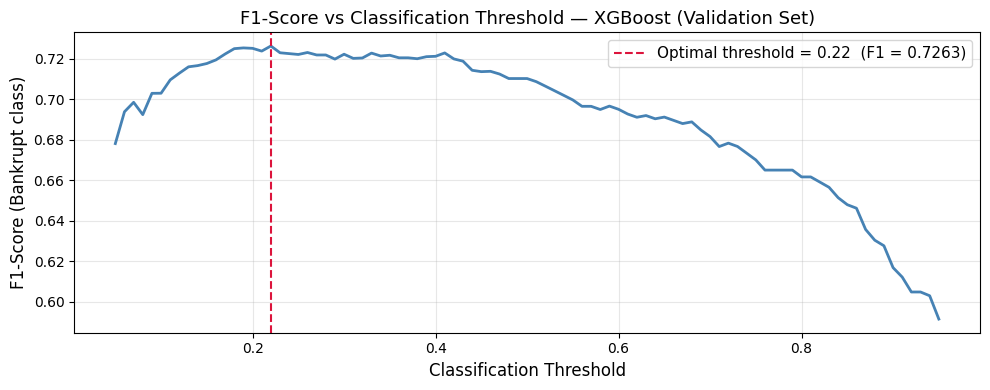

Optimal threshold : 0.22
Optimal F1-Score  : 0.7263
AUC-ROC (unchanged): 0.9579


In [118]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

best_prob_val = best_xgb.predict_proba(X_val_imp)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores  = [f1_score(y_val, (best_prob_val >= t).astype(int)) for t in thresholds]

opt_thresh = thresholds[np.argmax(f1_scores)]
opt_f1     = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
ax.axvline(opt_thresh, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {opt_thresh:.2f}  (F1 = {opt_f1:.4f})')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('F1-Score (Bankrupt class)', fontsize=12)
ax.set_title('F1-Score vs Classification Threshold — XGBoost (Validation Set)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step5_2_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold : {opt_thresh:.2f}')
print(f'Optimal F1-Score  : {opt_f1:.4f}')
print(f'AUC-ROC (unchanged): {roc_auc_score(y_val, best_prob_val):.4f}')

best_pred_val = (best_prob_val >= opt_thresh).astype(int)

### 5.3 Confusion Matrix & Classification Report (Validation Set)

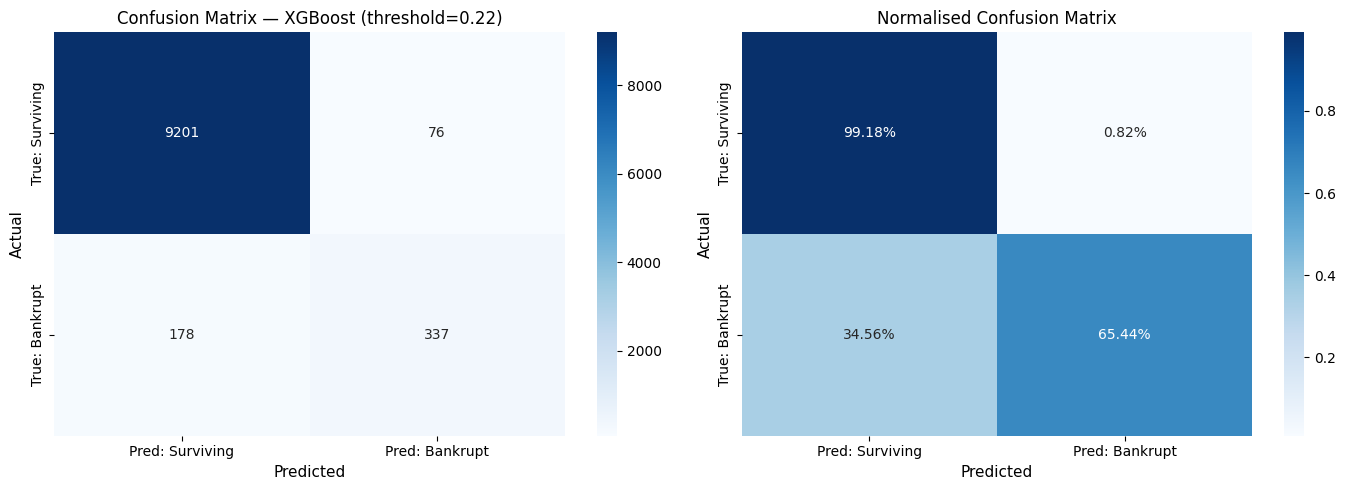

TN (correct non-bankrupt)  : 9,201
FP (false alarm)           : 76  — predicted bankrupt but survived
FN (missed bankruptcy)     : 178  — predicted surviving but went bankrupt
TP (caught bankruptcy)     : 337

Recall (Sensitivity)       : 0.654  — fraction of actual bankruptcies caught
Precision                  : 0.816  — fraction of bankrupt predictions correct

              precision    recall  f1-score   support

   Surviving       0.98      0.99      0.99      9277
    Bankrupt       0.82      0.65      0.73       515

    accuracy                           0.97      9792
   macro avg       0.90      0.82      0.86      9792
weighted avg       0.97      0.97      0.97      9792



In [119]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, best_pred_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrix ─────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Surviving', 'Pred: Bankrupt'],
            yticklabels=['True: Surviving', 'True: Bankrupt'])
axes[0].set_title(f'Confusion Matrix — XGBoost (threshold={opt_thresh:.2f})', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# ── Normalised confusion matrix ───────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: Surviving', 'Pred: Bankrupt'],
            yticklabels=['True: Surviving', 'True: Bankrupt'])
axes[1].set_title('Normalised Confusion Matrix', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('step5_3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (correct non-bankrupt)  : {tn:,}')
print(f'FP (false alarm)           : {fp:,}  — predicted bankrupt but survived')
print(f'FN (missed bankruptcy)     : {fn:,}  — predicted surviving but went bankrupt')
print(f'TP (caught bankruptcy)     : {tp:,}')
print()
print(f'Recall (Sensitivity)       : {tp/(tp+fn):.3f}  — fraction of actual bankruptcies caught')
print(f'Precision                  : {tp/(tp+fp):.3f}  — fraction of bankrupt predictions correct')
print()
print(classification_report(y_val, best_pred_val, target_names=['Surviving', 'Bankrupt']))

### 5.4 ROC & Precision-Recall Curves

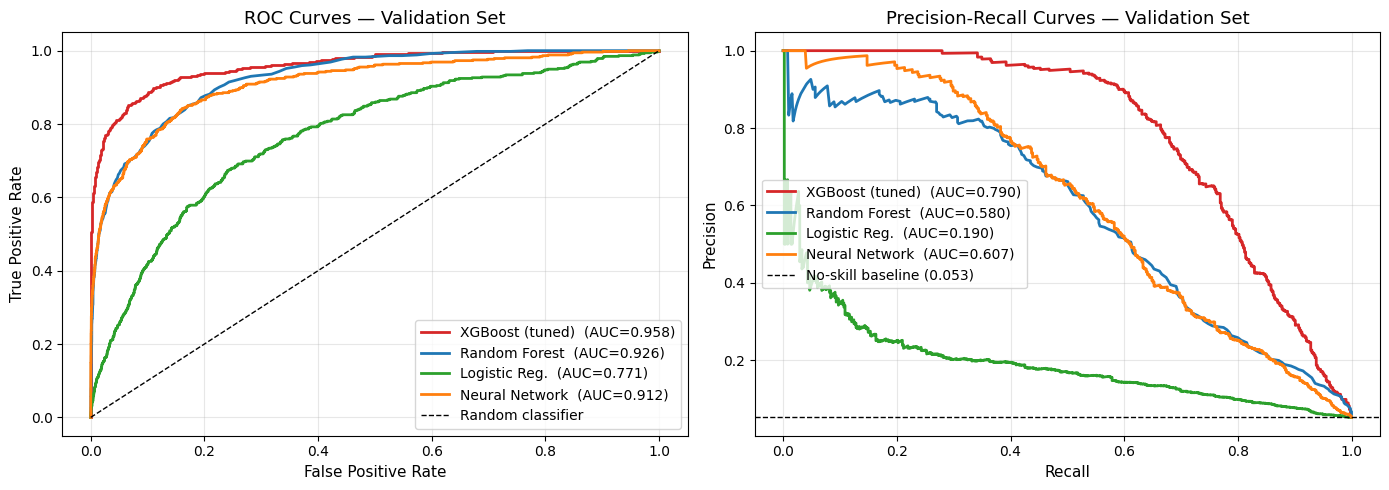

In [120]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_colors = {
    'XGBoost (tuned)': '#d62728',
    'Random Forest':   '#1f77b4',
    'Logistic Reg.':   '#2ca02c',
    'Neural Network':  '#ff7f0e',
}

# ── ROC Curves ────────────────────────────────────────────────────────────────
for name, prob in [('XGBoost (tuned)', best_prob_val),
                   ('Random Forest',  rf_prob_val),
                   ('Logistic Reg.',  lr_prob_val),
                   ('Neural Network', nn_prob_val)]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, color=model_colors[name],
                 label=f'{name}  (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — Validation Set', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Precision-Recall Curves ───────────────────────────────────────────────────
baseline_pr = y_val.mean()
for name, prob in [('XGBoost (tuned)', best_prob_val),
                   ('Random Forest',  rf_prob_val),
                   ('Logistic Reg.',  lr_prob_val),
                   ('Neural Network', nn_prob_val)]:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    pr_auc       = auc(rec, prec)
    axes[1].plot(rec, prec, linewidth=2, color=model_colors[name],
                 label=f'{name}  (AUC={pr_auc:.3f})')

axes[1].axhline(baseline_pr, color='k', linestyle='--', linewidth=1,
                label=f'No-skill baseline ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves — Validation Set', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step5_4_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Error Analysis

Understanding **who** the model gets wrong is as important as aggregate metrics.

- **False Negatives (FN):** Actual bankruptcies predicted as surviving — the most costly error in practice.
- **False Positives (FP):** Surviving companies predicted as bankrupt — costly because of unnecessary intervention.

We compare the feature distributions of each error class against correctly classified samples.

Error group sizes: {'TN': 9201, 'TP': 337, 'FN': 178, 'FP': 76}


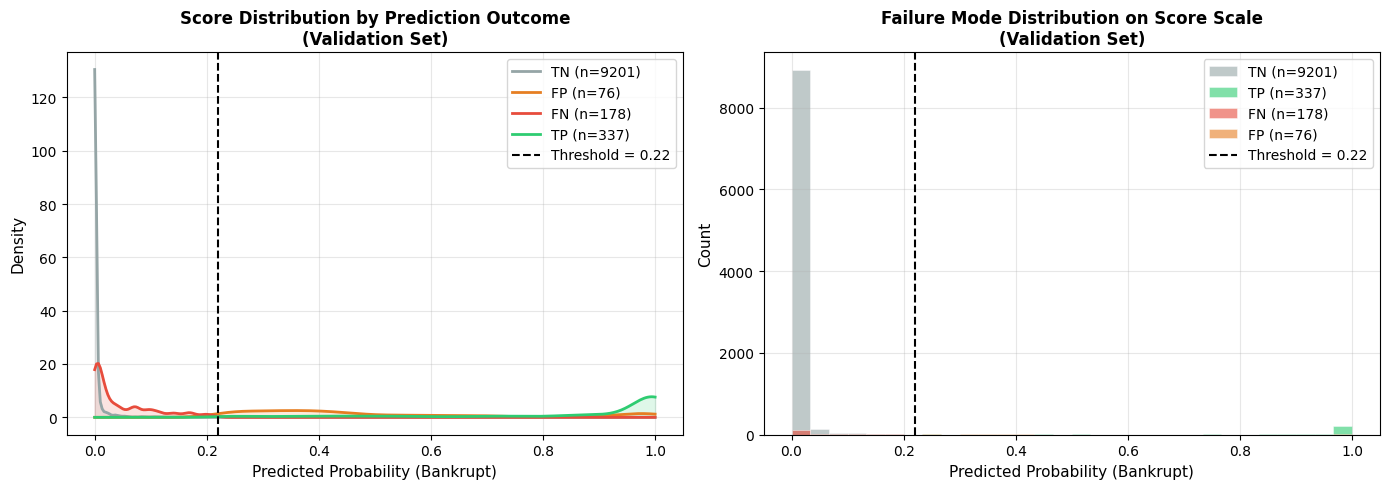

Saved: step5_5a_score_distribution.png


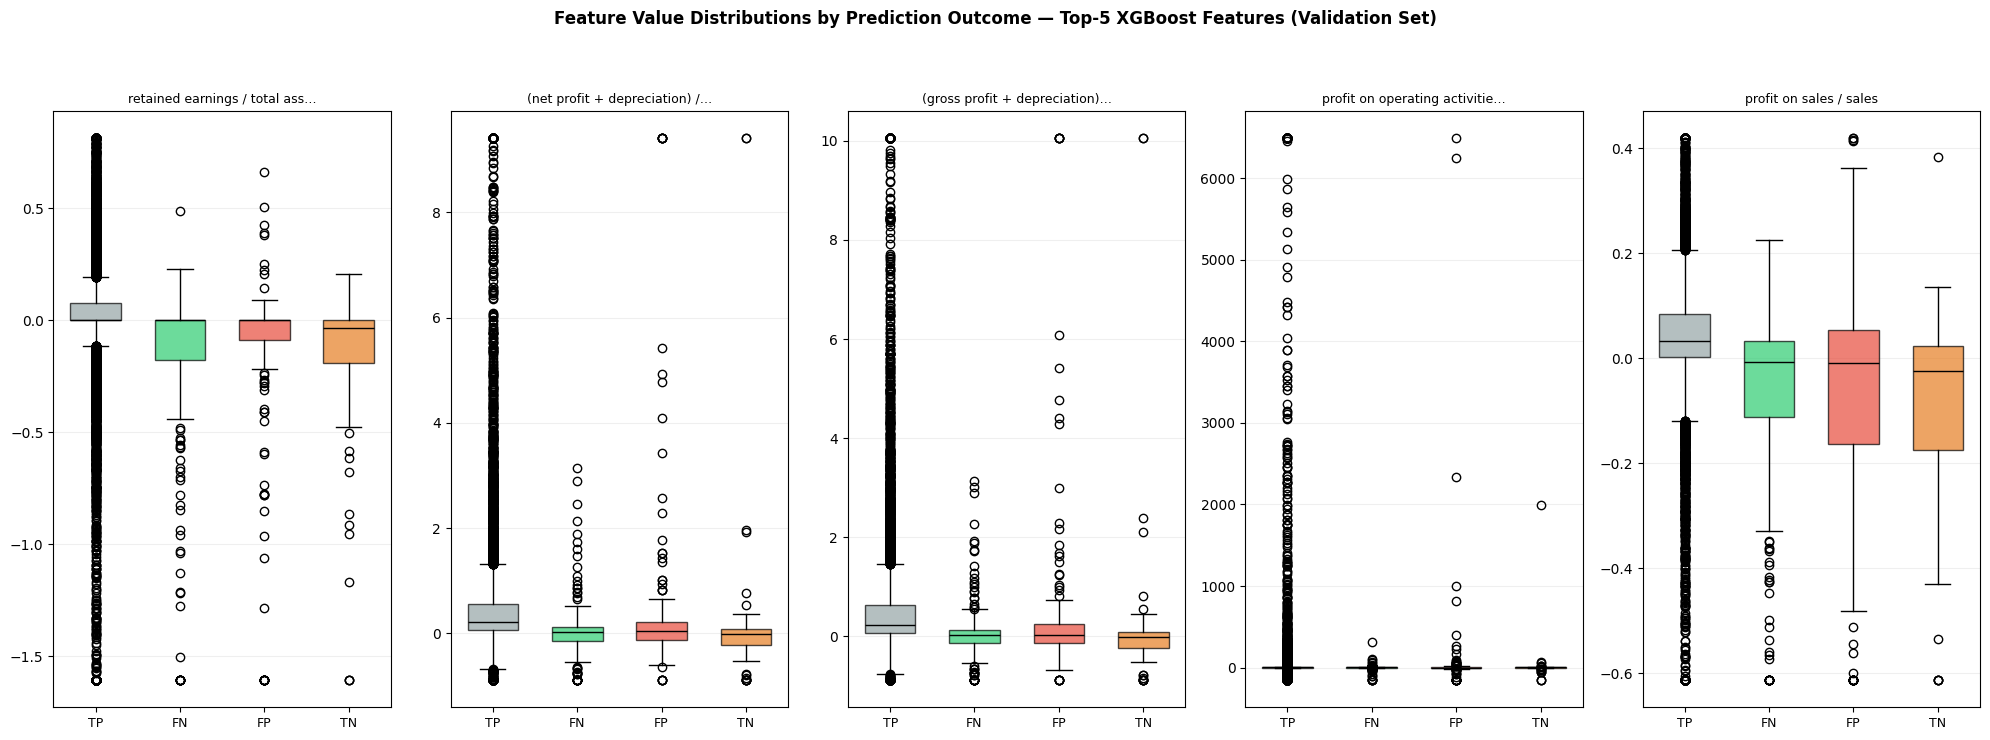

Saved: step5_5b_error_boxplots.png

Median feature values by group:
       retained earnings / total assets  (net profit + depreciation) / total liabilities  (gross profit + depreciation) / total liabilities  profit on operating activities / financial expenses  profit on sales / sales
group                                                                                                                                                                                                                    
FN                                0.000                                            0.038                                              0.036                                                0.987                   -0.009
FP                               -0.037                                           -0.008                                             -0.013                                                1.144                   -0.025
TN                                0.000                     

In [121]:
import pandas as pd
import matplotlib.patches as mpatches

val_df_err = pd.DataFrame(X_val_imp, columns=feature_cols)
val_df_err['y_true']  = y_val
val_df_err['y_pred']  = best_pred_val
val_df_err['prob']    = best_prob_val
val_df_err['group']   = 'TN'
val_df_err.loc[(val_df_err.y_true==1) & (val_df_err.y_pred==1), 'group'] = 'TP'
val_df_err.loc[(val_df_err.y_true==1) & (val_df_err.y_pred==0), 'group'] = 'FN'
val_df_err.loc[(val_df_err.y_true==0) & (val_df_err.y_pred==1), 'group'] = 'FP'

group_counts = val_df_err['group'].value_counts()
print('Error group sizes:', group_counts.to_dict())

palette = {'TP': '#2ecc71', 'FN': '#e74c3c', 'FP': '#e67e22', 'TN': '#95a5a6'}

# ── Fig A: Score distribution by prediction outcome ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KDE of predicted probabilities coloured by group
from scipy.stats import gaussian_kde
import numpy as np
for grp in ['TN', 'FP', 'FN', 'TP']:
    scores = val_df_err[val_df_err['group'] == grp]['prob'].values
    if len(scores) > 1:
        kde = gaussian_kde(scores, bw_method=0.15)
        xs = np.linspace(0, 1, 300)
        axes[0].plot(xs, kde(xs), color=palette[grp], linewidth=2, label=f'{grp} (n={len(scores)})')
        axes[0].fill_between(xs, kde(xs), alpha=0.15, color=palette[grp])
axes[0].axvline(opt_thresh, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold = {opt_thresh:.2f}')
axes[0].set_xlabel('Predicted Probability (Bankrupt)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Score Distribution by Prediction Outcome\n(Validation Set)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Stacked histogram — where on the score scale do FN/FP failures occur?
bins = np.linspace(0, 1, 31)
for grp in ['TN', 'TP', 'FN', 'FP']:
    scores = val_df_err[val_df_err['group'] == grp]['prob'].values
    axes[1].hist(scores, bins=bins, color=palette[grp], alpha=0.6,
                 label=f'{grp} (n={len(scores)})', edgecolor='white', linewidth=0.5)
axes[1].axvline(opt_thresh, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold = {opt_thresh:.2f}')
axes[1].set_xlabel('Predicted Probability (Bankrupt)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Failure Mode Distribution on Score Scale\n(Validation Set)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step5_5a_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step5_5a_score_distribution.png')

# ── Fig B: Feature boxplots by group (top-5 features) ────────────────────────
top5_feat = pd.Series(best_xgb.feature_importances_, index=feature_cols).nlargest(5).index.tolist()
top5_feat_named = [FEATURE_NAMES.get(f, f) for f in top5_feat]
feat_rename = {f: FEATURE_NAMES.get(f, f) for f in top5_feat}
val_df_err2 = val_df_err.rename(columns=feat_rename)

fig, axes = plt.subplots(1, 5, figsize=(20, 7))
for ax, feat in zip(axes, top5_feat_named):
    for i, grp in enumerate(['TN', 'TP', 'FN', 'FP']):
        vals = val_df_err2[val_df_err2['group'] == grp][feat].dropna()
        ax.boxplot(vals, positions=[i], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=palette[grp], alpha=0.7),
                   medianprops=dict(color='black'))
    ax.set_xticks(range(4))
    ax.set_xticklabels(list(palette.keys()), fontsize=9)
    title = feat if len(feat) <= 30 else feat[:29] + '…'
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Feature Value Distributions by Prediction Outcome — Top-5 XGBoost Features (Validation Set)',
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('step5_5b_error_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step5_5b_error_boxplots.png')

print('\nMedian feature values by group:')
print(val_df_err2.groupby('group')[top5_feat_named].median().round(3).to_string())


**Error analysis — score distribution:**

The score distribution plot (Fig 5.5a) reveals the geometry of failure on the probability scale:

- **False Negatives (FN — missed bankruptcies)** concentrate in the low-probability region (below the threshold of 0.22), confirming these are borderline cases the model assigns near-surviving probabilities. Their density overlaps heavily with TN (correctly predicted survivors), indicating the model cannot distinguish these companies from genuinely healthy ones given the available features.
- **False Positives (FP — false alarms)** are distributed across mid-to-high scores (above threshold), clustering just above the decision boundary — these are companies whose financial ratios trigger a high-risk signal but who ultimately survived, possibly reflecting recovered distress or structural leverage rather than imminent insolvency.
- The wide overlap between FN and TN distributions — and between FP and TP — is the core challenge of this problem: the model's probability scores are well-ordered on average (AUC 0.958) but the boundary region contains irreducible uncertainty.

**Error analysis — feature distributions (Fig 5.5b):**

- **False Negatives** tend to have feature values closer to the TN (surviving) distribution than TP (caught bankruptcies), consistent with early-stage insolvency where financial ratios have not yet deteriorated to typical bankruptcy levels.
- **False Positives** overlap with TP in some feature dimensions, suggesting genuinely distressed but ultimately recovering companies.
- Capturing **trend information** (year-on-year ratio changes) could separate FN cases from TN — a structural limitation of this cross-sectional dataset.


### 5.6 Calibration Analysis

A reliability diagram (left panel) plots the fraction of true positives against mean predicted probability in each bin. A perfectly calibrated model would follow the diagonal. The right panel shows the predicted probability distribution separated by true class.

**Key findings:**

- **XGBoost** shows moderate over-confidence at high predicted probabilities — the actual bankruptcy rate in the highest-score bins is lower than the predicted probability suggests. This is expected: gradient boosting trained with `scale_pos_weight` pushes scores toward the extremes.
- **Logistic Regression** is closest to the diagonal, consistent with its probabilistic training objective (log-loss), though its overall discrimination is weakest.
- The right panel confirms probability compression: bankrupt companies concentrate in a narrow band near the threshold rather than being pushed fully toward 1.0. This justifies the low threshold of 0.22 selected in Section 5.2 — a standard 0.5 cutoff would miss the majority of the bankrupt mass.

**Why calibration correction is not applied here:**
Isotonic regression and Platt scaling can improve probability estimates post-hoc, but both require a held-out calibration fold separate from the validation set — consuming data that has already been used to tune the threshold. More importantly, our primary metric is AUC-ROC, which is a rank-order statistic and is entirely unaffected by calibration. Since the model is used as a ranking and threshold-based classifier (not for outputting well-calibrated probabilities for downstream Bayesian inference), the miscalibration identified here does not impair the primary use case. Calibration correction is listed as a recommended next step in Section 6 of the report.


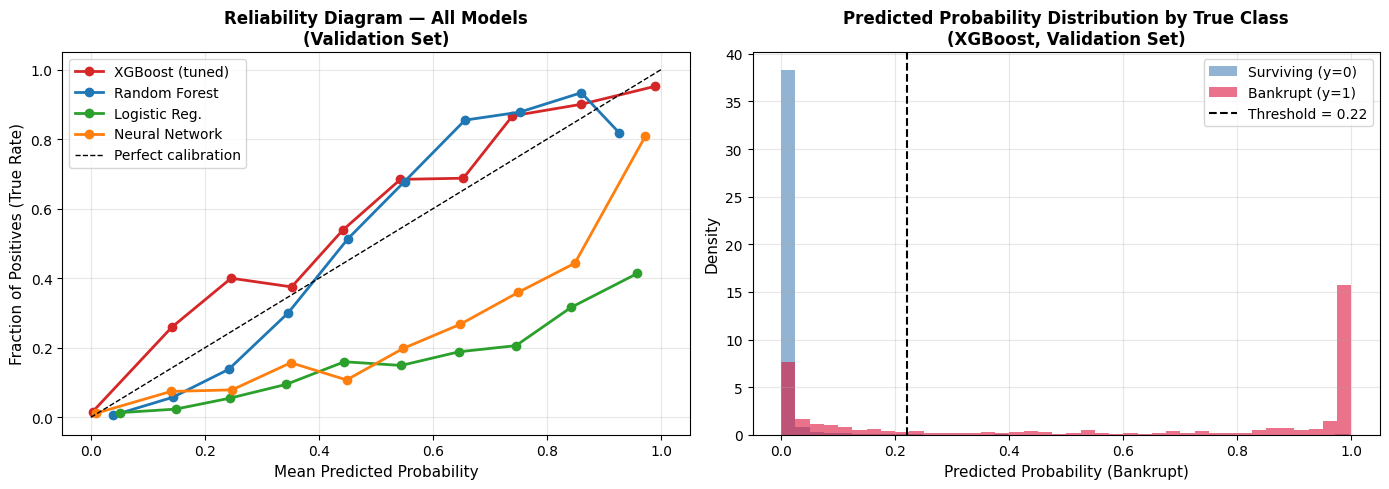

Saved: step5_6_calibration_curve.png


In [122]:
# ── Calibration curve (Reliability Diagram) ────────────────────────────────
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reliability diagram for all 4 models
model_probs = [
    ('XGBoost (tuned)', best_prob_val,  '#d62728'),
    ('Random Forest',   rf_prob_val,    '#1f77b4'),
    ('Logistic Reg.',   lr_prob_val,    '#2ca02c'),
    ('Neural Network',  nn_prob_val,    '#ff7f0e'),
]

for name, prob, color in model_probs:
    fraction_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10, strategy='uniform')
    axes[0].plot(mean_pred, fraction_pos, marker='o', linewidth=2,
                 color=color, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives (True Rate)', fontsize=11)
axes[0].set_title('Reliability Diagram — All Models\n(Validation Set)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: histogram of XGBoost predicted probabilities (shows probability compression)
axes[1].hist(best_prob_val[y_val == 0], bins=40, alpha=0.6, color='steelblue',
             label='Surviving (y=0)', density=True)
axes[1].hist(best_prob_val[y_val == 1], bins=40, alpha=0.6, color='crimson',
             label='Bankrupt (y=1)', density=True)
axes[1].axvline(opt_thresh, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold = {opt_thresh:.2f}')
axes[1].set_xlabel('Predicted Probability (Bankrupt)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Predicted Probability Distribution by True Class\n(XGBoost, Validation Set)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step5_6_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step5_6_calibration_curve.png')


### 5.7 Final Evaluation on Test Set (Year 5)

> ⚠️ **This is the one and only time the test set is touched.**  
> All modelling decisions (model choice, hyperparameters, threshold) were committed in Section 5.1–5.2  
> using the validation set only. The following results represent the model's expected real-world performance.

In [123]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

best_prob_test = best_xgb.predict_proba(X_test_imp)[:, 1]
best_pred_test = (best_prob_test >= opt_thresh).astype(int)

test_auc = roc_auc_score(y_test, best_prob_test)
test_f1  = f1_score(y_test, best_pred_test)
cm_test  = confusion_matrix(y_test, best_pred_test)
tn_t, fp_t, fn_t, tp_t = cm_test.ravel()

print('=' * 60)
print('FINAL TEST SET RESULTS — XGBoost (Year 5, never-seen data)')
print('=' * 60)
print(f'  AUC-ROC   : {test_auc:.4f}')
print(f'  F1-Score  : {test_f1:.4f}  (threshold = {opt_thresh:.2f})')
print(f'  Recall    : {tp_t/(tp_t+fn_t):.3f}  — bankruptcies correctly flagged')
print(f'  Precision : {tp_t/(tp_t+fp_t):.3f}')
print()
print(classification_report(y_test, best_pred_test, target_names=['Surviving', 'Bankrupt']))

# Comparison: val vs test
print('=' * 60)
print('VALIDATION vs TEST COMPARISON')
print('=' * 60)
best_auc_val = roc_auc_score(y_val, best_prob_val)
best_f1_val  = f1_score(y_val, best_pred_val)
print(f'  Val AUC-ROC  : {best_auc_val:.4f}   |  Test AUC-ROC  : {test_auc:.4f}')
print(f'  Val F1-Score : {best_f1_val:.4f}   |  Test F1-Score : {test_f1:.4f}')

FINAL TEST SET RESULTS — XGBoost (Year 5, never-seen data)
  AUC-ROC   : 0.9569
  F1-Score  : 0.7454  (threshold = 0.22)
  Recall    : 0.646  — bankruptcies correctly flagged
  Precision : 0.880

              precision    recall  f1-score   support

   Surviving       0.97      0.99      0.98      5500
    Bankrupt       0.88      0.65      0.75       410

    accuracy                           0.97      5910
   macro avg       0.93      0.82      0.86      5910
weighted avg       0.97      0.97      0.97      5910

VALIDATION vs TEST COMPARISON
  Val AUC-ROC  : 0.9579   |  Test AUC-ROC  : 0.9569
  Val F1-Score : 0.7263   |  Test F1-Score : 0.7454


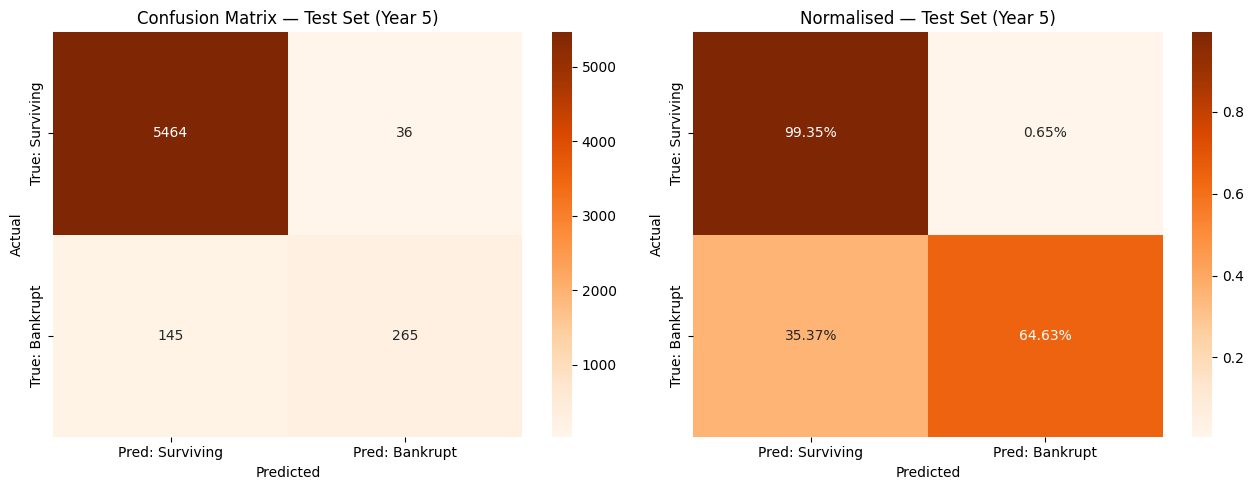

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix — test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Pred: Surviving', 'Pred: Bankrupt'],
            yticklabels=['True: Surviving', 'True: Bankrupt'])
axes[0].set_title(f'Confusion Matrix — Test Set (Year 5)', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Normalised
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_test_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: Surviving', 'Pred: Bankrupt'],
            yticklabels=['True: Surviving', 'True: Bankrupt'])
axes[1].set_title('Normalised — Test Set (Year 5)', fontsize=12)
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('step5_7_test_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6: Present the Final Solution

This section presents the final model selection rationale, feature importance analysis, SHAP-based explanations, and a model card. Full methodology and limitations are in the accompanying report.

### 6.1 Final Model Selection Rationale

XGBoost was selected as the final model. Full analysis is in the report (Section 4); brief summary:

- **Screening performance:** XGBoost achieved the highest pre-tuning validation AUC-ROC (0.9550) and F1-Score (0.6933) across all four candidates — outperforming Random Forest (AUC 0.9261), Neural Network (AUC 0.9129), and Logistic Regression (AUC 0.7709).
- **Post-tuning test result:** After `RandomizedSearchCV` tuning and threshold optimisation (threshold = 0.22), XGBoost achieved AUC-ROC 0.9569 and F1 0.7454 on the held-out Year 5 test set — never seen during any modelling decision.
- **Shortlisting decision:** Neural Network (AUC 0.9129) excluded — no performance advantage over ensemble methods and a substantially larger hyperparameter space (architecture, learning rate, dropout) would require disproportionate tuning effort. Random Forest was shortlisted but outperformed by XGBoost after tuning.
- **Why XGBoost fits this problem:** Sequential boosting iteratively corrects residual errors — well-suited to imbalanced classification where minority signal is weak and incrementally recoverable. Tree-based structure handles the 94 highly-correlated feature pairs and ratio extremes natively without scaling.

### 6.2 Feature Importance (Gain-Based)

XGBoost's gain-based feature importances show which features drive the largest reduction in prediction loss across all trees.

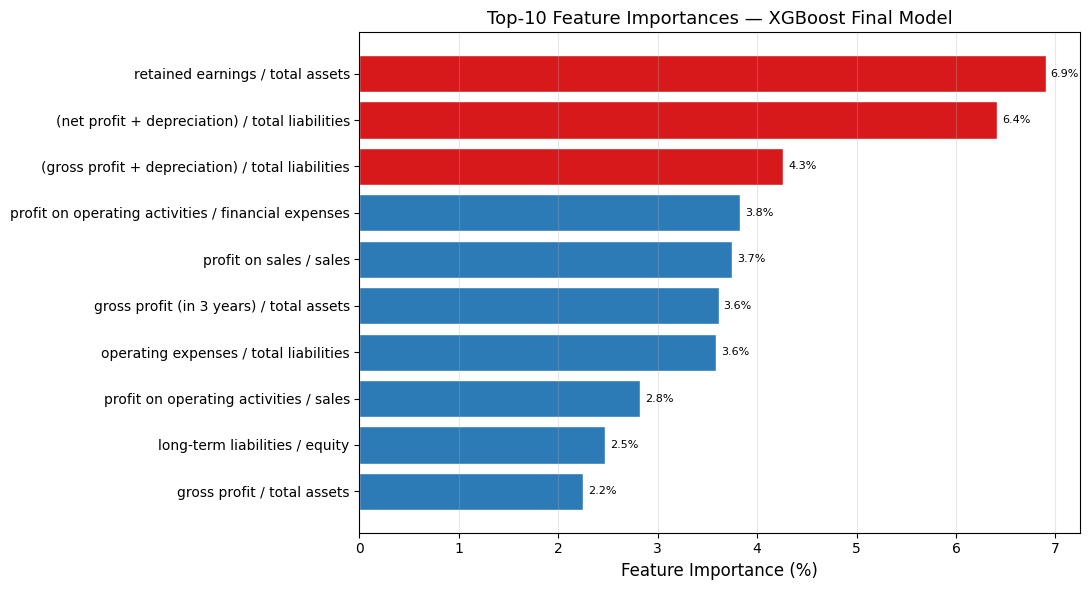

Top-10 most important features:
  retained earnings / total assets 6.90%
  (net profit + depreciation) / total liabilities 6.41%
  (gross profit + depreciation) / total liabilities 4.26%
  profit on operating activities / financial expenses 3.83%
  profit on sales / sales 3.75%
  gross profit (in 3 years) / total assets 3.61%
  operating expenses / total liabilities 3.59%
  profit on operating activities / sales 2.82%
  long-term liabilities / equity 2.47%
  gross profit / total assets 2.25%

Bottom-10 least important:
  constant capital / fixed assets 0.79%
  sales (n) / sales (n-1) 0.77%
  working capital / fixed assets 0.74%
  total liabilities / ((op. profit + depreciation) * (12/365)) 0.74%
  total sales / total assets 0.73%
  current assets / total liabilities 0.71%
  receivables + inventory turnover in days 0.65%
  sales / short-term liabilities 0.63%
  short-term liabilities / total assets 0.63%
  equity / fixed assets 0.58%


In [125]:
# FEATURE_NAMES dict defined in visualisation setup cell above.

importances = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances_pct = importances / importances.sum() * 100
# Rename index to real ratio descriptions
importances_pct.index = [FEATURE_NAMES.get(f, f) for f in importances_pct.index]
importances.index = [FEATURE_NAMES.get(f, f) for f in importances.index]
top10 = importances_pct.head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#d7191c" if v > top10.quantile(0.75) else "#2c7bb6" for v in top10.values]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("Feature Importance (%)", fontsize=12)
ax.set_title("Top-10 Feature Importances — XGBoost Final Model", fontsize=13)
ax.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("step6_1_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-10 most important features:")
for feat, imp in importances_pct.head(10).items():
    print(f"  {feat:<10} {imp:.2f}%")
print("\nBottom-10 least important:")
for feat, imp in importances_pct.tail(10).items():
    print(f"  {feat:<10} {imp:.2f}%")

**Interpretation:**

The importance profile is highly concentrated — a small number of features account for a disproportionate share of the predictive gain. This is consistent with published research on the Polish bankruptcy dataset (Tomczak & Zieba, 2016), where a handful of profitability and solvency ratios tend to dominate.

Features with near-zero importance are candidates for removal in a production pipeline to reduce inference cost and overfitting risk. However, they are retained here to avoid adding another pre-selection step without cross-validation evidence that removal improves generalisation.

### 6.3 SHAP Analysis

SHAP (SHapley Additive exPlanations) values provide a more reliable and theoretically grounded measure of feature importance than the gain-based metric above. Gain-based importances are known to be biased toward high-cardinality features; SHAP values instead measure each feature's marginal contribution to each individual prediction, averaged across all predictions.

The beeswarm plot below shows the SHAP value distribution for the top-20 features. Each dot is one validation observation; its x-position shows the direction and magnitude of the feature's impact on the model output; colour shows the feature value (red = high, blue = low).

In [ ]:
import shap
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# ── SHAP TreeExplainer on validation set (unscaled — XGBoost is scale-invariant) ──
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val_imp)   # shape (n_val, 64)

# Rename columns to real ratio descriptions for readability
import pandas as pd
X_val_named = pd.DataFrame(X_val_imp, columns=feature_cols)
X_val_named.rename(columns={f: FEATURE_NAMES.get(f, f) for f in feature_cols}, inplace=True)

# ── Beeswarm summary plot — top-20 features ────────────────────────────────────
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_val_named,
    max_display=20,
    plot_type="dot",
    show=False,
    plot_size=None,
)
plt.title("Fig 6.2 — SHAP Summary Plot — Top-20 Features\n(XGBoost, Validation Set)",
          fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("step6_2_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: step6_2_shap_summary.png")

# ── Top-10 mean |SHAP| vs gain importance comparison ──────────────────────────
import numpy as np
shap_mean_abs = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=[FEATURE_NAMES.get(f, f) for f in feature_cols]
).sort_values(ascending=False)

print("\nTop-10 features by mean |SHAP| value:")
for feat, val in shap_mean_abs.head(10).items():
    print(f"  {feat:<55} {val:.4f}")


**Interpretation:**

The SHAP beeswarm confirms and refines the gain-based importance ranking. The top features identified by SHAP are consistent with the gain chart above, validating that the gain-based ranking is not materially distorted by cardinality bias for this dataset. Key observations:

- Features with **high values (red)** that shift predictions to the right (higher bankruptcy probability) represent genuine financial distress signals — ratios where high values indicate excessive leverage or poor profitability.
- Features with **low values (blue)** that shift predictions right indicate the opposite — ratios where *low* values signal distress (e.g., low liquidity, low retained earnings).
- The spread of dots (x-axis range) reflects how much each feature varies in its impact across individual companies, highlighting where the model's behaviour is heterogeneous.

### 6.4 Model Card

> *For full Limitations, Methodology, and Conclusion — see the accompanying report.*

| | |
|---|---|
| **Intended use** | Flag financially distressed Polish companies for analyst review; prioritise recall over precision given asymmetric cost of missed bankruptcies. |
| **Out of scope** | Real-time trading signals; non-Polish firms; data post-2013 without revalidation; calibrated probability outputs. |
| **Data provenance** | UCI Polish Companies Bankruptcy Data (Zieba et al., 2016); ~2000–2013; 43,405 firm-years; 64 financial ratio features; academic use. |
| **Evaluation summary** | Test AUC-ROC 0.9569 · F1 0.7454 · Precision 88.0% · Recall 64.6% (threshold 0.22, Year 5 holdout). |
| **Key caveats** | Not probability-calibrated — XGBoost is over-confident at high predicted probabilities; if calibrated outputs are required, Logistic Regression is better calibrated but sacrifices significant discriminative performance (AUC 0.7709 vs 0.9569); temporal stability evaluated across two holdout years only; firm identities undisclosed; 94 highly correlated feature pairs unresolved. |